# School performance predictions: 
# Ensuring fairness for disadvantaged students 

## 0) Imports

In [34]:
import os
import copy
import math
import json
import collections
from IPython.display import display, HTML
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import get_scorer
from sklearn.preprocessing import KBinsDiscretizer
from fairlearn import metrics
from fairlearn.metrics import demographic_parity_difference, demographic_parity_ratio
import ipywidgets as widgets

In [35]:
import torch

#if torch.cuda.is_available():
#    device = torch.device("cuda")
#else:
device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cpu


## 1) Data Loading, Cleaning and Understanding

### Preliminary Observations

In [36]:
df = pd.read_csv("students-dataset/benchmark/dataset.csv", low_memory=False)
df = df.set_index("id_questionnaire")
print(df.shape)
df.head()

(80174, 159)


,id_student_original,id_year,id_grade,id_class_group,id_school,id_student_16_19,id_school_16_19,score_MAT,level_MAT,score_LEN,...,t_extent_of_student_involvement_during_class,t_extent_of_teaching_methods_variety,t_extent_of_opinion_on_school,t_extent_of_class_behaviour,t_extent_of_resource_variety,t_extent_of_good_work_by_non_teachers,t_number_of_individual_training_topics,t_number_of_subjects_taught,t_extent_of_satisfaction_job_and_school,t_extent_of_results_satisfaction
id_questionnaire,,,,,,,,,,,,,,,,,,,,,
1,33613.0,2016,3,A,2415.0,14374.0,569.0,564.87,3.0,535.15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19294.0,2016,3,A,1842.0,8001.0,273.0,388.34,1.0,293.70,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,19587.0,2016,3,NaN,1432.0,8142.0,82.0,386.59,1.0,514.81,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,29985.0,2016,3,A,2280.0,12800.0,505.0,487.76,2.0,449.25,...,0.555556,0.666667,1.0,0.500000,0.458333,0.555556,NaN,NaN,NaN,0.666667
5,6982.0,2016,3,A,2040.0,2606.0,390.0,709.79,4.0,598.72,...,0.666667,0.733333,1.0,0.833333,0.625000,0.888889,1.0,NaN,NaN,1.000000


In [37]:
df.groupby(by=["id_year", "id_grade"])[["id_year", "id_grade"]].count()

id_year  id_grade
id_year id_grade                   
2016    3           19466     19466
        6           19928     19928
2017    3            3056      3056
        4            2931      2931
        6            3110      3110
2018    3            3238      3238
        4            3106      3106
        6            3277      3277
2019    4            3199      3199
        6           18863     18863

<Axes: ylabel='id_year,id_grade'>

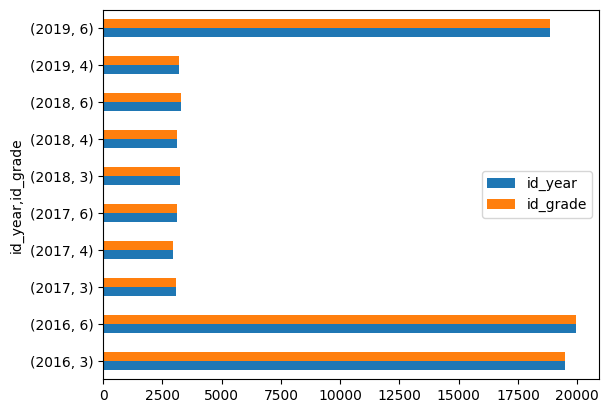

In [38]:
df.groupby(by=["id_year", "id_grade"])[["id_year", "id_grade"]].count().plot.barh()

In [39]:
TARGET = widgets.Dropdown(
    options=['level_MAT', 'level_ENG', 'level_LEN'],
    value='level_MAT',
    description='Target:',
    disabled=False,
)
display(TARGET)

Dropdown(description='Target:', options=('level_MAT', 'level_ENG', 'level_LEN'), value='level_MAT')

In [40]:
SENSITIVE = widgets.Dropdown(
    options=['f_ESCS', 'gender'],
    value='f_ESCS',
    description='Sensitive:',
    disabled=False,
)
display(SENSITIVE)


Dropdown(description='Sensitive:', options=('f_ESCS', 'gender'), value='f_ESCS')

In [41]:
YEAR = widgets.Dropdown(
    options=[('2016', 2016), ('2017', 2017), ('2018', 2018), ('2019', 2019)],
    value= 2016,
    description='Year:',
    disabled=False,
)
display(YEAR)

Dropdown(description='Year:', options=(('2016', 2016), ('2017', 2017), ('2018', 2018), ('2019', 2019)), value=…

In [42]:
GRADE = widgets.Dropdown(
    options=df[df['id_year']==YEAR.value]['id_grade'].unique().tolist(),
    value=6,
    description='Grade:',
    disabled=False,
)
display(GRADE)

Dropdown(description='Grade:', index=1, options=(3, 6), value=6)

In [43]:
style = {'description_width': 'initial', 'width':'750px'}
MISS_THRESH_S = widgets.FloatSlider(
    value=0.1,
    min=0,
    max=1,
    step=0.1,
    description='Max % missing in student:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    style=style,
    layout=widgets.Layout(width='500px', height='50px')
)
MISS_THRESH_F = widgets.FloatSlider(
    value=0.3,
    min=0,
    max=1,
    step=0.1,
    description='Max % missing in family:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    style=style,
    layout=widgets.Layout(width='500px', height='50px')
)
MISS_THRESH_T = widgets.FloatSlider(
    value=0.3,
    min=0,
    max=1,
    step=0.1,
    description='Max % missing in teacher:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    style=style,
    layout=widgets.Layout(width='500px', height='50px')
)
MISS_THRESH_P = widgets.FloatSlider(
    value=0.1,
    min=0,
    max=1,
    step=0.1,
    description='Max % missing in principal:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    style=style,
    layout=widgets.Layout(width='500px', height='50px')
)
MISS_THRESH_FINAL = widgets.FloatSlider(
    value=0.1,
    min=0,
    max=1,
    step=0.1,
    description='Max % missing in final:',
    disabled=False,
    continuous_update=False,
    orientation='horizontal',
    readout=True,
    readout_format='.1f',
    style=style,
    layout=widgets.Layout(width='500px', height='50px')
)

display(MISS_THRESH_S)
display(MISS_THRESH_F)
display(MISS_THRESH_T)
display(MISS_THRESH_P)
display(MISS_THRESH_FINAL)

FloatSlider(value=0.1, continuous_update=False, description='Max % missing in student:', layout=Layout(height=…

FloatSlider(value=0.3, continuous_update=False, description='Max % missing in family:', layout=Layout(height='…

FloatSlider(value=0.3, continuous_update=False, description='Max % missing in teacher:', layout=Layout(height=…

FloatSlider(value=0.1, continuous_update=False, description='Max % missing in principal:', layout=Layout(heigh…

FloatSlider(value=0.1, continuous_update=False, description='Max % missing in final:', layout=Layout(height='5…

In [44]:
RAND_STATE = 42
SENSITIVE = SENSITIVE.value
TARGET = TARGET.value
YEAR = YEAR.value
GRADE = GRADE.value
MISS_THRESH_S = MISS_THRESH_S.value
MISS_THRESH_F = MISS_THRESH_F.value
MISS_THRESH_T = MISS_THRESH_T.value
MISS_THRESH_P = MISS_THRESH_P.value
MISS_THRESH_FINAL = MISS_THRESH_FINAL.value

In [45]:
df[["id_year", "id_grade", SENSITIVE]].groupby(by=["id_year", "id_grade"])[SENSITIVE].count()


id_year  id_grade
2016     3           13964
         6           14702
2017     3            1549
         4            2889
         6            1872
2018     3            2929
         4            3030
         6            2922
2019     4            3116
         6           11784
Name: f_ESCS, dtype: int64

In [46]:
df[["id_year", "id_grade", TARGET]].groupby(by=["id_year", "id_grade"])[TARGET].count()


id_year  id_grade
2016     3           17806
         6           17916
2017     3            2995
         4            2362
         6            3031
2018     3            3102
         4            2397
         6            3186
2019     4            2385
         6           18019
Name: level_MAT, dtype: int64

In [47]:
df_sel = df[(df["id_year"] == YEAR) & (df["id_grade"] == GRADE)]
df_sel = df_sel[df_sel[TARGET].notna()]
print(df_sel.shape)
print(df_sel[SENSITIVE].isna().sum())

(17916, 159)
4471


In [48]:
df_sel[SENSITIVE].describe()

count    13445.000000
mean         0.036848
std          0.990857
min         -2.648533
25%         -0.708813
50%          0.019550
75%          0.664128
max          3.062709
Name: f_ESCS, dtype: float64

### Feature Study

#### Utility Functions

Filtering dataset based on questionnaire scope.

In [49]:
def filter_columns_starting_with(temp_df, pattern):
    df = copy.deepcopy(temp_df)
    if pattern is not None:
        return df[[col for col in df.columns if col.startswith(pattern)] + [col for col in df.columns if col.startswith("level_")]]
    else:
        return df

Extracting the percentage of missing values.

In [50]:
def get_missing_values(temp_df):
    df = copy.deepcopy(temp_df)
    return df.isna().sum()/df.shape[0]


Discretizing columns value when necessary.

In [51]:
def discretize_columns(temp_df):
    df = copy.deepcopy(temp_df)
    categorical_features = df.select_dtypes(include=['object', 'category']).columns
    # Apply Ordinal Encoding
    encoder = OrdinalEncoder()
    df[categorical_features] = encoder.fit_transform(df[categorical_features])
    return df


Showing correlation matrix.

In [52]:
def compute_correlation_matrix(temp_df, annot=True):
    df = copy.deepcopy(temp_df)
    correlation_matrix = df.corr()
    ax = sns.heatmap(correlation_matrix, annot=annot, cmap='coolwarm', fmt=".2f")
    ax.collections[0].set_clim(-1, 1)
    plt.title("Correlation Matrix Heatmap")
    plt.show()
    return correlation_matrix

Full method to analyse data.

In [53]:
def compute_analysis(df, column_pattern, missing_threshold=0.1, annot=True):
    df_filtered = filter_columns_starting_with(df, column_pattern)
    missings = get_missing_values(df_filtered)
    good_missings = missings[missings < missing_threshold]
    print(f"FEATURES WITH ENOUGH VALUES: {good_missings.shape[0]}")
    print(good_missings)
    print()
    bad_missings = missings[missings > missing_threshold]
    print(f"BAD FEATURES: {bad_missings.shape[0]}")
    print(bad_missings)
    print()
    df_without_bad_cols = df_filtered.drop(bad_missings.index, axis=1)
    df_discretized = discretize_columns(df_without_bad_cols)
    correlation_matrix = compute_correlation_matrix(df_discretized, annot)
    return df_without_bad_cols, correlation_matrix

FEATURES WITH ENOUGH VALUES: 9
id_student_original    0.000000
id_year                0.000000
id_grade               0.000000
id_class_group         0.149978
id_school              0.000000
id_school_16_19        0.054253
level_MAT              0.000000
level_LEN              0.012391
level_ING              0.015908
dtype: float64

BAD FEATURES: 0
Series([], dtype: float64)



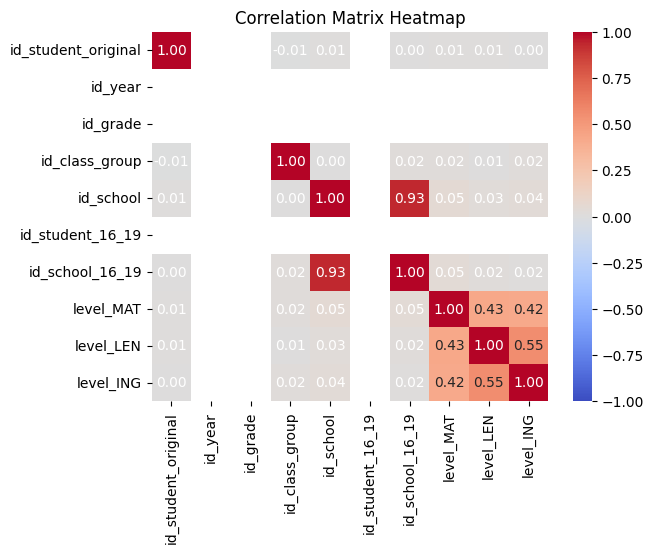

In [54]:
df_sel_gen, correlation_matrix_general = compute_analysis(df=df_sel, column_pattern="id_", missing_threshold=1.0, annot=True)

FEATURES WITH ENOUGH VALUES: 18
s_gender                             0.000000
s_birth_year                         0.045825
s_is_living_with_mother              0.072003
s_frequency_of_skips                 0.051797
s_homeworks_day_per_week             0.039071
s_extent_of_teachers_affinity        0.060728
s_frequency_of_computer_usage        0.048560
s_frequency_of_internet_usage        0.049620
s_frequency_of_work_with_teachers    0.048392
s_frequency_of_materials_in_class    0.052244
s_frequency_of_evaluations           0.050625
s_extent_of_teacher_performance      0.050904
s_extent_of_class_env                0.053695
s_extent_of_classmates_affinity      0.053360
s_extent_of_school_satisfaction      0.050011
level_MAT                            0.000000
level_LEN                            0.012391
level_ING                            0.015908
dtype: float64

BAD FEATURES: 9
s_is_living_with_father             0.152657
s_is_living_with_siblings           0.381670
s_is_living_with_o

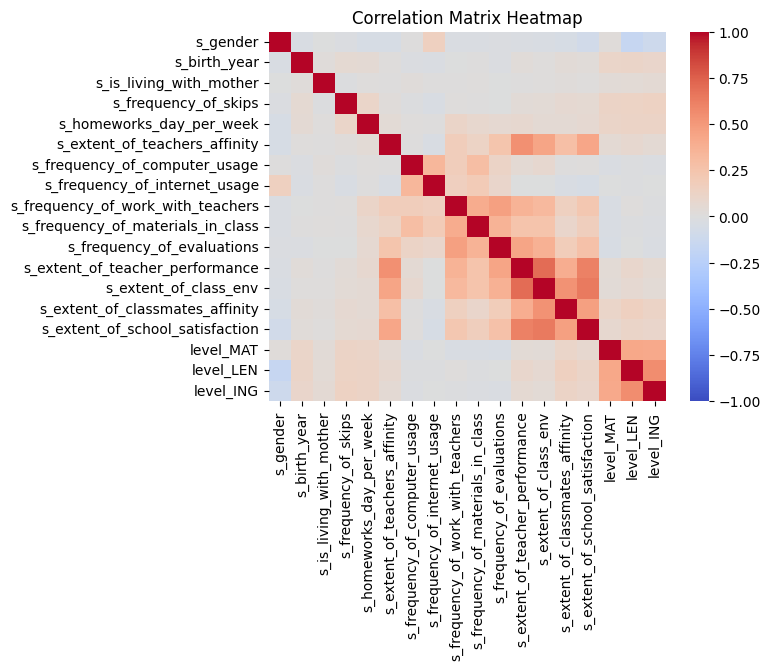

In [55]:
df_sel_students, correlation_matrix_sel_students = compute_analysis(df=df_sel, column_pattern="s_",
                                                                     missing_threshold=MISS_THRESH_S, annot=False)

FEATURES WITH ENOUGH VALUES: 27
f_respondent                                           0.266633
f_number_of_people_in_household                        0.275675
f_mother_age                                           0.259600
f_mother_education_level                               0.268922
f_mother_employment_status                             0.286615
f_mother_place_of_birth                                0.299732
f_student_place_of_birth                               0.269871
f_language_spoken_at_home                              0.260772
f_degree_of_start_schooling_age                        0.269926
f_number_of_tech_at_home                               0.256698
f_extent_of_books_at_home                              0.248828
f_visits_in_school_by_mother                           0.265070
f_has_been_recommended_school                          0.255526
f_number_of_homework_hours_a_week                      0.254186
f_mother_occupation                                    0.281034
f_ESCS  

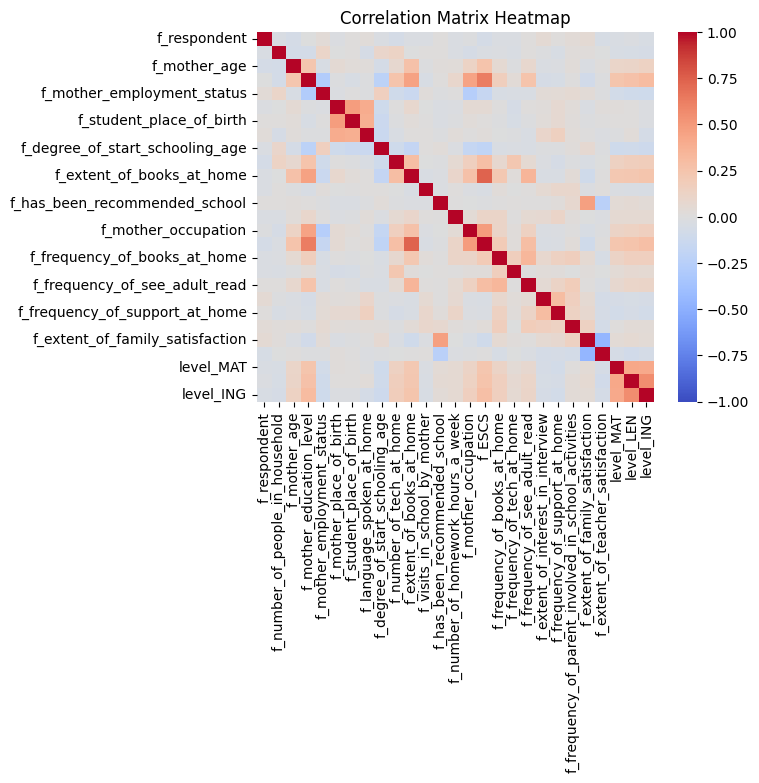

In [56]:
df_sel_families, correlation_matrix_sel_families = compute_analysis(df=df_sel, column_pattern="f_",
                                                                     missing_threshold=MISS_THRESH_F, annot=False)

FEATURES WITH ENOUGH VALUES: 3
level_MAT    0.000000
level_LEN    0.012391
level_ING    0.015908
dtype: float64

BAD FEATURES: 37
t_gender                                                 0.317816
t_age                                                    0.324291
t_number_of_years_as_teacher                             0.317872
t_number_of_years_in_school                              0.323510
t_has_taught_same_group_last_two_years                   0.315640
t_number_of_students_in_group                            0.320496
t_number_of_students_disadvanteged_economic_situation    0.688770
t_number_of_foreign_students_speaking_spanish            0.510828
t_number_of_foreign_students_not_speaking_spanish        0.483367
t_number_of_teaching_hours_per_week                      0.324291
t_average_explanation_time                               0.314747
t_degree_of_individual_training_incidence                0.356944
t_seat_configuration                                     0.317537
t_behaviour_

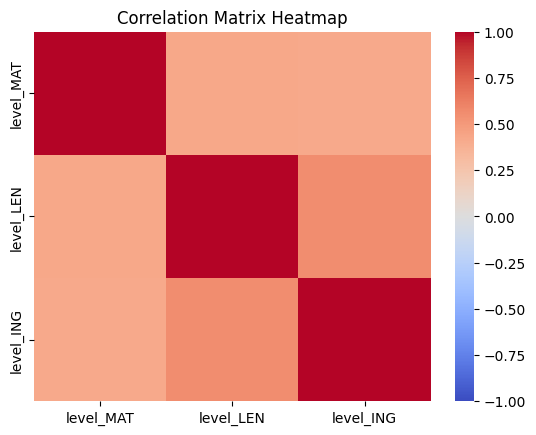

In [57]:
df_sel_teachers, correlation_matrix_sel_teachers = compute_analysis(df=df_sel, column_pattern="t_",
                                                                     missing_threshold=MISS_THRESH_T, annot=False)

FEATURES WITH ENOUGH VALUES: 36
p_gender                                             0.042141
p_number_of_teachers_in_school                       0.048169
p_percentage_of_teachers_changed_school_last_year    0.042532
p_attitude_teacher_training_courses                  0.050737
p_age                                                0.045044
p_group_criteria_random                              0.000000
p_group_criteria_subjects                            0.000000
p_group_criteria_other                               0.000000
p_group_criteria_alphabet                            0.000000
p_group_criteria_gender                              0.000000
p_group_criteria_language                            0.000000
p_group_criteria_performance                         0.000000
p_group_criteria_homogeneity                         0.000000
p_group_criteria_heterogeneity                       0.000000
p_number_of_years_of_teaching                        0.052523
p_number_of_years_in_school           

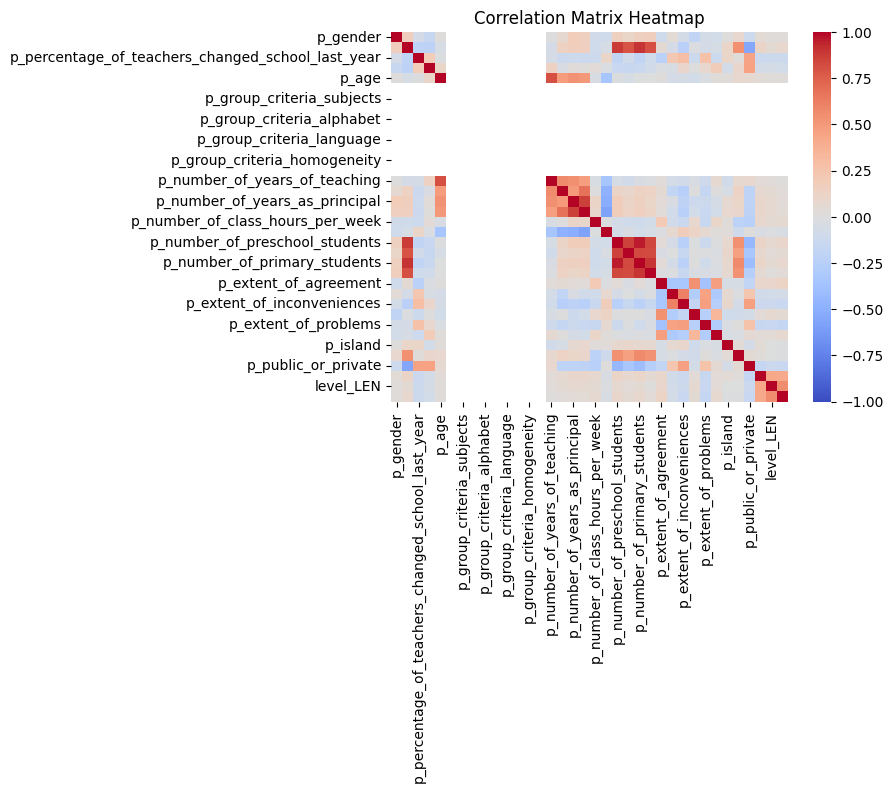

In [58]:
df_sel_principals, correlation_matrix_sel_principals = compute_analysis(df=df_sel, column_pattern="p_",
                                                                         missing_threshold=MISS_THRESH_P, annot=False)

### Feature Importance

In [59]:
get_features = lambda curr_df: [col for col in curr_df.columns if not col.startswith("level_")]
concatenated_df = pd.concat(
    [
    df_sel_gen[["id_class_group", "id_school", TARGET]],
    df_sel_students[get_features(df_sel_students)],
    df_sel_families[get_features(df_sel_families)],
    df_sel_teachers[get_features(df_sel_teachers)],
    df_sel_principals[get_features(df_sel_principals)]
    ],
    axis=1
    )
X, y = concatenated_df[get_features(concatenated_df)],concatenated_df[TARGET]

In [60]:
forest = RandomForestClassifier(random_state=RAND_STATE)
forest.fit(discretize_columns(X), y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [61]:
importances = forest.feature_importances_
std = np.std([tree.feature_importances_ for tree in forest.estimators_], axis=0)

Text(0, 0.5, 'Mean decrease in impurity')

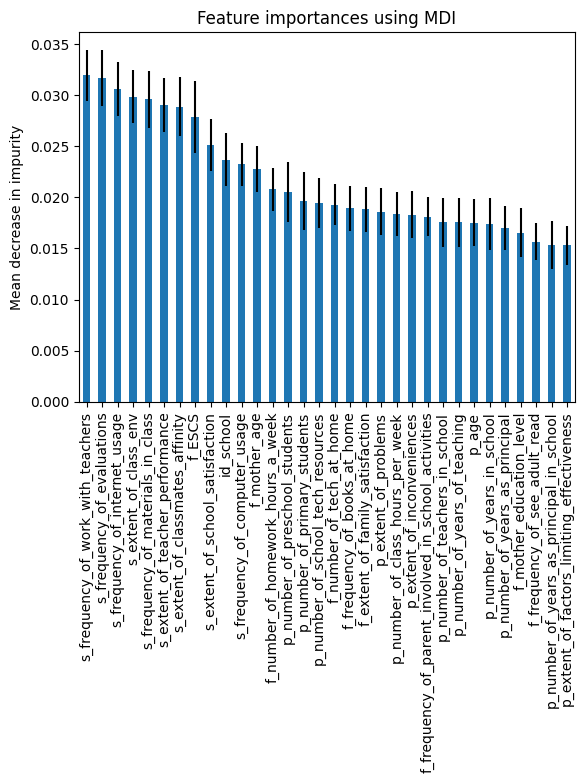

In [62]:
forest_importances = pd.Series(importances, index=get_features(concatenated_df))
forest_std = pd.Series(std, index=get_features(concatenated_df))
forest_df = pd.concat([forest_importances, forest_std], axis=1)
forest_df.columns = ["importance", "std"]
forest_df = forest_df[forest_df["importance"] > 0.015]
forest_df = forest_df.sort_values("importance", ascending=False)
forest_importances = forest_df["importance"]
std = forest_df["std"].to_numpy()
fig, ax = plt.subplots()
forest_importances.plot.bar(yerr=std, ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")

## 2) Bias and Proxy Detection

### Bias detection

In [63]:
final_features = [col for col in list(forest_importances.index) if col != "id_school"]
final_features

['s_frequency_of_work_with_teachers',
 's_frequency_of_evaluations',
 's_frequency_of_internet_usage',
 's_extent_of_class_env',
 's_frequency_of_materials_in_class',
 's_extent_of_teacher_performance',
 's_extent_of_classmates_affinity',
 'f_ESCS',
 's_extent_of_school_satisfaction',
 's_frequency_of_computer_usage',
 'f_mother_age',
 'f_number_of_homework_hours_a_week',
 'p_number_of_preschool_students',
 'p_number_of_primary_students',
 'p_number_of_school_tech_resources',
 'f_number_of_tech_at_home',
 'f_frequency_of_books_at_home',
 'f_extent_of_family_satisfaction',
 'p_extent_of_problems',
 'p_number_of_class_hours_per_week',
 'p_extent_of_inconveniences',
 'f_frequency_of_parent_involved_in_school_activities',
 'p_number_of_teachers_in_school',
 'p_number_of_years_of_teaching',
 'p_age',
 'p_number_of_years_in_school',
 'p_number_of_years_as_principal',
 'f_mother_education_level',
 'f_frequency_of_see_adult_read',
 'p_number_of_years_as_principal_in_school',
 'p_extent_of_fact

In [64]:
final_df = concatenated_df[final_features + [TARGET]]

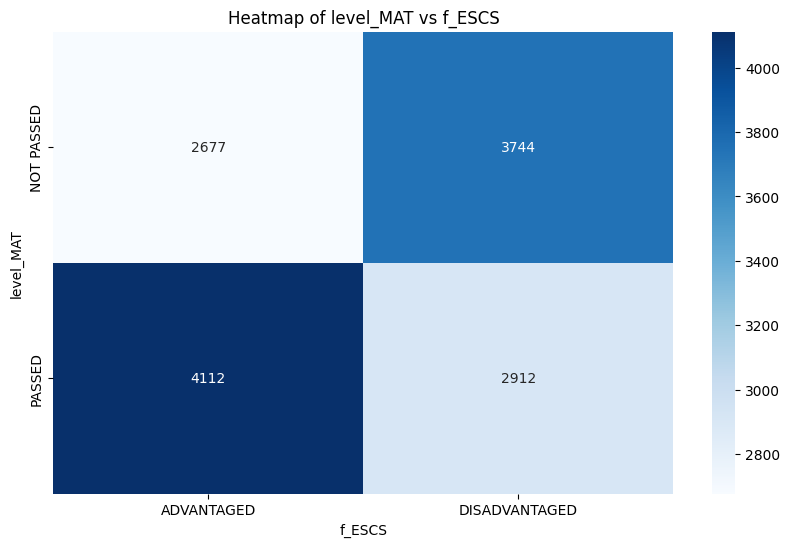

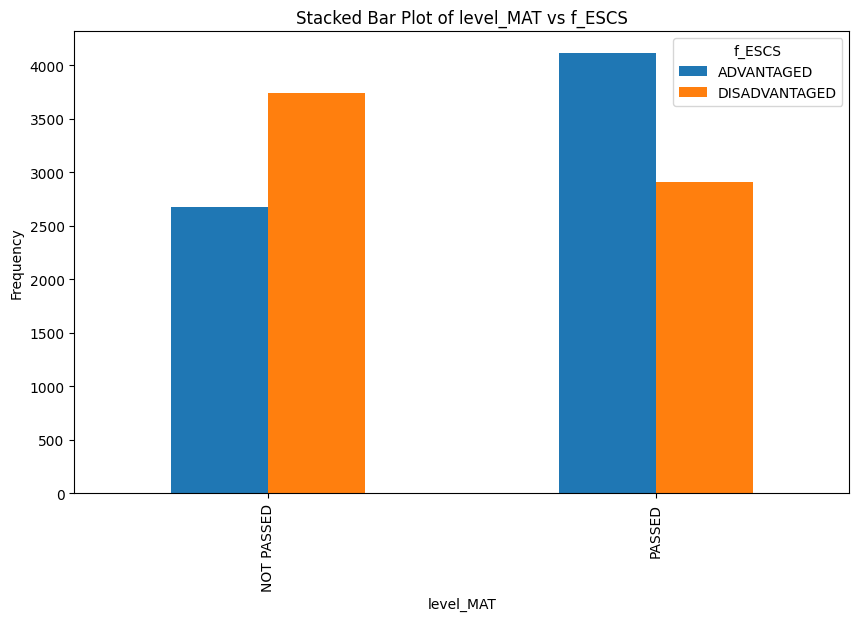

In [65]:
favorable_sensitive_label = "ADVANTAGED"
unfavorable_sensitive_label = "DISADVANTAGED"
favorable_class_label = "PASSED"
unfavorable_class_label = "NOT PASSED"
trial_df = final_df[[TARGET, SENSITIVE]]
trial_df = trial_df.dropna()
trial_df[SENSITIVE] = trial_df[SENSITIVE].apply(lambda elem: favorable_sensitive_label if elem > 0.0 else unfavorable_sensitive_label)
trial_df[TARGET] = trial_df[TARGET].apply(lambda elem: favorable_class_label if elem >= 2.5 else unfavorable_class_label)
col_a = trial_df[TARGET]
col_b = trial_df[SENSITIVE]
crosstab = pd.crosstab(col_a, col_b)
# Heatmap of Frequency
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='Blues')
plt.title(f'Heatmap of {TARGET} vs {SENSITIVE}')
plt.xlabel(SENSITIVE)
plt.ylabel(TARGET)
plt.show()
# Clustered Bar Plot
crosstab.plot(kind='bar', stacked=False, figsize=(10, 6))
plt.title(f'Stacked Bar Plot of {TARGET} vs {SENSITIVE}')
plt.xlabel(TARGET)
plt.ylabel('Frequency')
plt.legend(title=SENSITIVE)
plt.show()


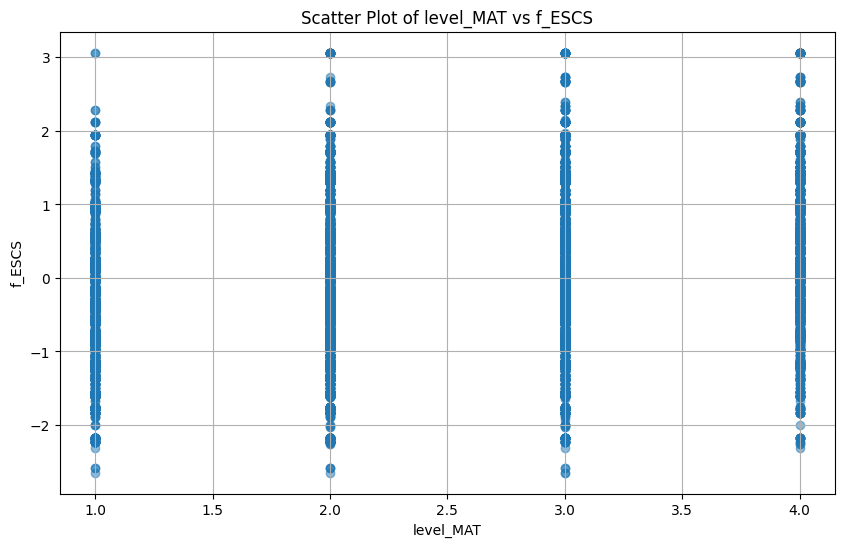

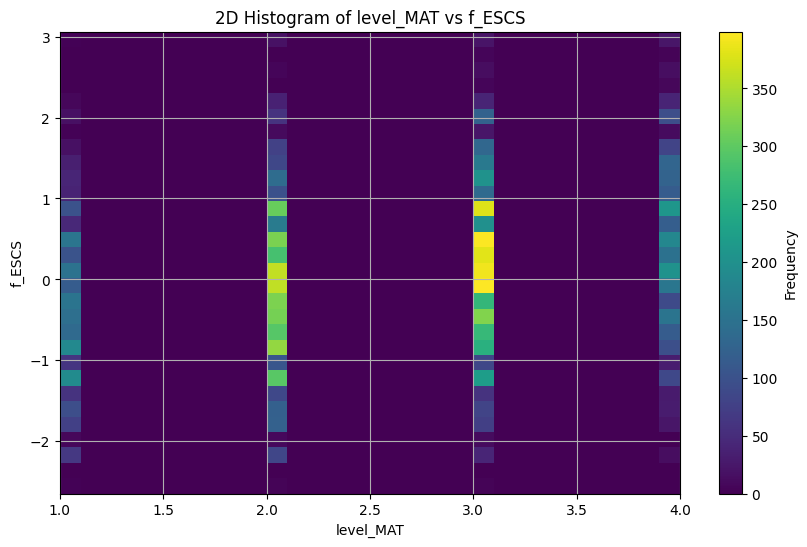

In [66]:
trial_df = final_df[[TARGET, SENSITIVE]]
trial_df = trial_df.dropna()
col_a = trial_df[TARGET]
col_b = trial_df[SENSITIVE]
# Scatter Plot
plt.figure(figsize=(10, 6))
plt.scatter(col_a, col_b, alpha=0.5)
plt.title(f"Scatter Plot of {TARGET} vs {SENSITIVE}")
plt.xlabel(TARGET)
plt.ylabel(SENSITIVE)
plt.grid()
plt.show()
# 2D Histogram (Heatmap)
plt.figure(figsize=(10, 6))
plt.hist2d(col_a, col_b, bins=(30, 30), cmap=plt.cm.viridis)
plt.colorbar(label='Frequency')
plt.title(f"2D Histogram of {TARGET} vs {SENSITIVE}")
plt.xlabel(TARGET)
plt.ylabel(SENSITIVE)
plt.grid()
plt.show()


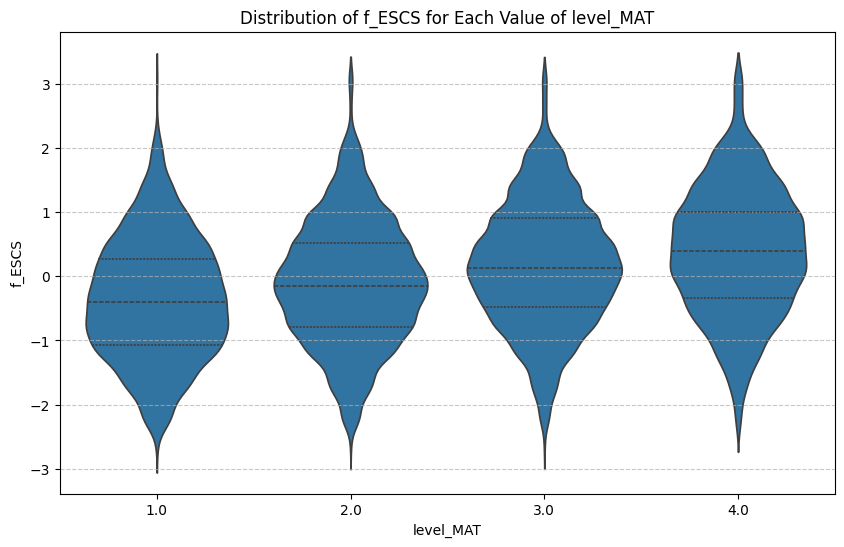

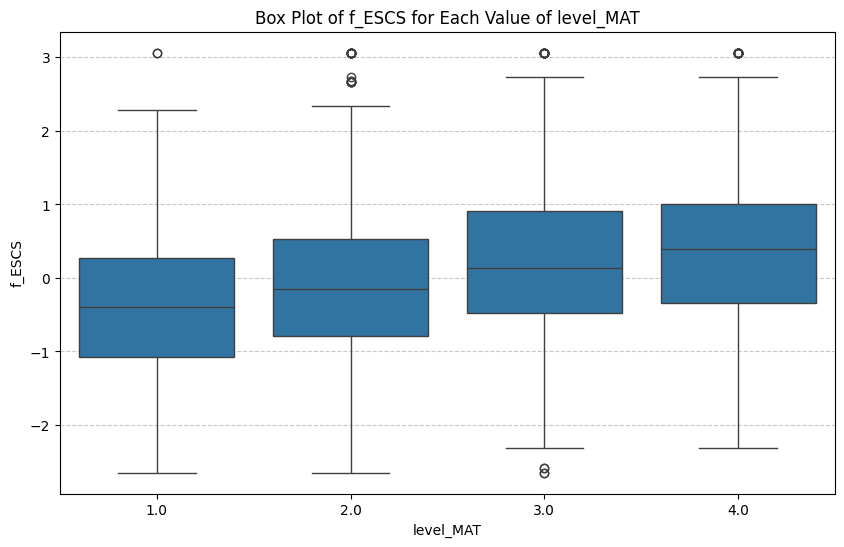

In [67]:
plt.figure(figsize=(10, 6))
sns.violinplot(x=TARGET, y=SENSITIVE, data=trial_df, inner="quartile")
plt.title(f'Distribution of {SENSITIVE} for Each Value of {TARGET}')
plt.xlabel(TARGET)
plt.ylabel(SENSITIVE)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
# Box Plot
plt.figure(figsize=(10, 6))
sns.boxplot(x=TARGET, y=SENSITIVE, data=trial_df)
plt.title(f'Box Plot of {SENSITIVE} for Each Value of {TARGET}')
plt.xlabel(TARGET)
plt.ylabel(SENSITIVE)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [68]:
final_df.head()

,s_frequency_of_work_with_teachers,s_frequency_of_evaluations,s_frequency_of_internet_usage,s_extent_of_class_env,s_frequency_of_materials_in_class,s_extent_of_teacher_performance,s_extent_of_classmates_affinity,f_ESCS,s_extent_of_school_satisfaction,s_frequency_of_computer_usage,...,p_number_of_teachers_in_school,p_number_of_years_of_teaching,p_age,p_number_of_years_in_school,p_number_of_years_as_principal,f_mother_education_level,f_frequency_of_see_adult_read,p_number_of_years_as_principal_in_school,p_extent_of_factors_limiting_effectiveness,level_MAT
id_questionnaire,,,,,,,,,,,,,,,,,,,,,
20431,0.700000,0.629630,0.666667,0.583333,0.666667,0.700000,0.761905,1.702062,0.722222,0.444444,...,41.0,30.0,59.0,25.0,16.0,4.0,0.500,16.0,0.291667,3.0
20432,0.777778,0.814815,0.266667,0.875000,0.476190,0.900000,0.761905,-0.541375,0.666667,0.222222,...,41.0,23.0,50.0,17.0,9.0,3.0,0.125,9.0,0.375000,3.0
20433,0.733333,0.703704,0.400000,0.916667,0.476190,1.000000,1.000000,0.943191,1.000000,0.444444,...,29.0,26.0,55.0,13.0,3.0,3.0,1.000,3.0,0.291667,3.0
20434,0.633333,0.629630,0.266667,0.750000,0.476190,0.766667,0.904762,-0.759225,0.722222,0.666667,...,5.0,20.0,57.0,1.0,2.0,3.0,0.250,1.0,0.625000,1.0
20435,0.666667,0.629630,0.266667,0.666667,0.523810,0.833333,0.809524,1.938398,0.888889,0.111111,...,57.0,26.0,55.0,4.0,14.0,6.0,0.125,2.0,0.500000,3.0


### Analysis of final dataset

In [69]:
final_df = final_df[~final_df.isnull().any(axis=1)]


FEATURES WITH ENOUGH VALUES: 32
s_frequency_of_work_with_teachers                      0.0
s_frequency_of_evaluations                             0.0
s_frequency_of_internet_usage                          0.0
s_extent_of_class_env                                  0.0
s_frequency_of_materials_in_class                      0.0
s_extent_of_teacher_performance                        0.0
s_extent_of_classmates_affinity                        0.0
f_ESCS                                                 0.0
s_extent_of_school_satisfaction                        0.0
s_frequency_of_computer_usage                          0.0
f_mother_age                                           0.0
f_number_of_homework_hours_a_week                      0.0
p_number_of_preschool_students                         0.0
p_number_of_primary_students                           0.0
p_number_of_school_tech_resources                      0.0
f_number_of_tech_at_home                               0.0
f_frequency_of_books_at_

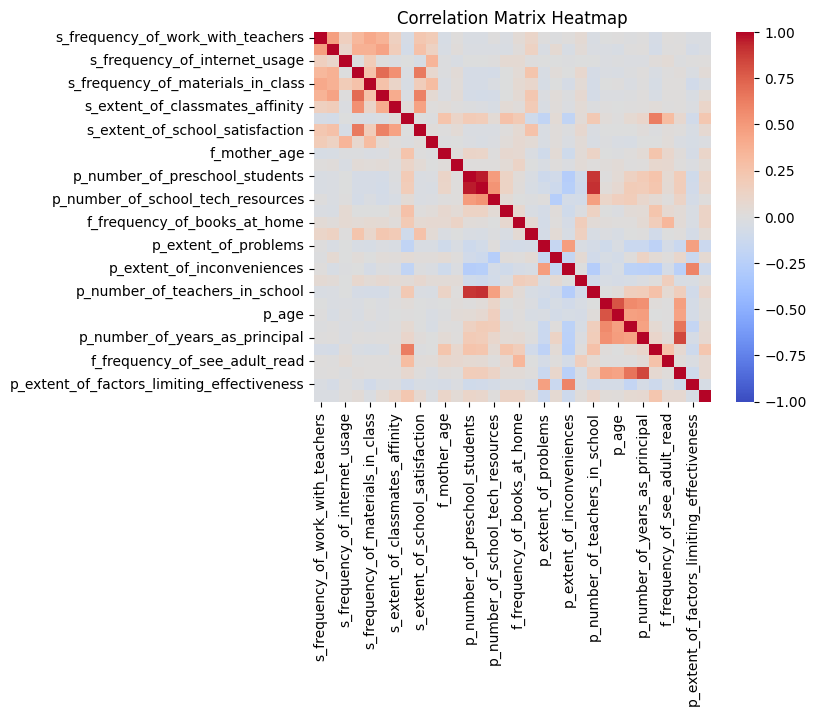

In [70]:
_, final_correlation = compute_analysis(df=final_df, column_pattern=None, missing_threshold=MISS_THRESH_FINAL, annot=False)


In [71]:
final_df.to_csv("final_df.csv")

### Proxy Detection

In [72]:
def find_proxies(feature, correlation, threshold=0.8):

    proxies = []
    proxy_header = True
    for i in correlation[feature].index:
        if (correlation[feature][i]>=threshold or correlation[feature][i]<=-threshold) and i!=feature:
            if proxy_header:
                print(f"\nProxy detected for {feature}:")
                proxy_header=False
                proxies.append(i)
            print(f"-----> {i} correlation: {round(correlation[feature][i],2)}")
    if not proxies:
        print(f"\nNo proxies detected for {feature}.")
    return proxies

In [73]:
target_proxies = find_proxies(TARGET, final_correlation, threshold=0.8)
sensitive_proxies = find_proxies(SENSITIVE, final_correlation, threshold=0.8)


No proxies detected for level_MAT.

No proxies detected for f_ESCS.


In [74]:
def compute_demographic_parity_difference(df):
    dpd = demographic_parity_difference(y_true=df[TARGET], y_pred=df[TARGET], sensitive_features=df[SENSITIVE])
    print(f"Demographic parity difference of {TARGET} on {SENSITIVE}: {dpd}")
    return dpd


In [75]:
def compute_demographic_parity_ratio(df):
    dpr = demographic_parity_ratio(y_true=df[TARGET], y_pred=df[TARGET], sensitive_features=df[SENSITIVE])
    print(f"Demographic parity ratio of {TARGET} on {SENSITIVE}: {dpr}")
    return dpr

In [76]:
dpd = compute_demographic_parity_difference(final_df)
dpr = compute_demographic_parity_ratio(final_df)

Demographic parity difference of level_MAT on f_ESCS: 1.0
Demographic parity ratio of level_MAT on f_ESCS: 0.0


## 3) Training and Testing

In [77]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import torch
np.random.seed(42)
torch.manual_seed(42)
from torch import nn
from fairlib.preprocessing import Reweighing, DisparateImpactRemover, LFR
from fairlib.inprocessing import Fauci, AdversarialDebiasing, PrejudiceRemover
from fairlib import DataFrame as DataFrameFL

In [78]:
final_df = pd.read_csv('final_df.csv', low_memory=False, index_col='id_questionnaire')
final_df.head()

,s_frequency_of_work_with_teachers,s_frequency_of_evaluations,s_frequency_of_internet_usage,s_extent_of_class_env,s_frequency_of_materials_in_class,s_extent_of_teacher_performance,s_extent_of_classmates_affinity,f_ESCS,s_extent_of_school_satisfaction,s_frequency_of_computer_usage,...,p_number_of_teachers_in_school,p_number_of_years_of_teaching,p_age,p_number_of_years_in_school,p_number_of_years_as_principal,f_mother_education_level,f_frequency_of_see_adult_read,p_number_of_years_as_principal_in_school,p_extent_of_factors_limiting_effectiveness,level_MAT
id_questionnaire,,,,,,,,,,,,,,,,,,,,,
20431,0.700000,0.629630,0.666667,0.583333,0.666667,0.700000,0.761905,1.702062,0.722222,0.444444,...,41.0,30.0,59.0,25.0,16.0,4.0,0.500,16.0,0.291667,3.0
20432,0.777778,0.814815,0.266667,0.875000,0.476190,0.900000,0.761905,-0.541375,0.666667,0.222222,...,41.0,23.0,50.0,17.0,9.0,3.0,0.125,9.0,0.375000,3.0
20433,0.733333,0.703704,0.400000,0.916667,0.476190,1.000000,1.000000,0.943191,1.000000,0.444444,...,29.0,26.0,55.0,13.0,3.0,3.0,1.000,3.0,0.291667,3.0
20434,0.633333,0.629630,0.266667,0.750000,0.476190,0.766667,0.904762,-0.759225,0.722222,0.666667,...,5.0,20.0,57.0,1.0,2.0,3.0,0.250,1.0,0.625000,1.0
20435,0.666667,0.629630,0.266667,0.666667,0.523810,0.833333,0.809524,1.938398,0.888889,0.111111,...,57.0,26.0,55.0,4.0,14.0,6.0,0.125,2.0,0.500000,3.0


In [79]:
final_df[TARGET].value_counts()

level_MAT
3.0    3627
2.0    3309
4.0    1766
1.0    1424
Name: count, dtype: int64

In [80]:
final_df[SENSITIVE] = final_df[SENSITIVE].apply(lambda elem: 1 if elem > 0.0 else 0)
final_df[TARGET] = final_df[TARGET].apply(lambda elem: 1 if elem >= 2.5 else 0)

In [81]:
display(final_df[TARGET].value_counts())
display(final_df[SENSITIVE].value_counts())

level_MAT
1    5393
0    4733
Name: count, dtype: int64

f_ESCS
1    5241
0    4885
Name: count, dtype: int64

In [82]:
final_df.to_csv('preprocessed_df.csv')

In [83]:
final_df= pd.read_csv('preprocessed_df.csv', low_memory=False, index_col='id_questionnaire')

In [84]:
X = final_df.drop(columns=[TARGET])
Y = final_df[TARGET]

In [85]:
col_map = {name: i for i, name in enumerate(X.columns)}
inv_map = {v: k for k, v in col_map.items()}

We notice that there are no categorical columns left after the pre-processing.

In [86]:
class BaseModel(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        #nn.Dropout(0.2),
        #nn.BatchNorm1d(hidden_dim),
        nn.ReLU(),
        nn.Linear(hidden_dim, hidden_dim),
        #nn.Dropout(0.2),
        #nn.BatchNorm1d(hidden_dim),
         nn.ReLU(),
         nn.Linear(hidden_dim, hidden_dim//2),
        # #nn.Dropout(0.2),
         nn.ReLU(),
         nn.Linear(hidden_dim//2, hidden_dim//4),
        #nn.Dropout(0.2),
        nn.ReLU(),
        nn.Linear(hidden_dim//4, 1),
    )

    def forward(self, x):
        return self.net(x)

In [87]:
def prepare_data_for_NN(X_train, Y_train, X_test=None, Y_test=None, imputer=None, scaler=None):
        
    if scaler:    
        X_train = scaler.transform(X_train)
    else:
        scaler = MinMaxScaler()#StandardScaler()
        X_train = scaler.fit_transform(X_train)

    X_train = pd.DataFrame(X_train, columns = inv_map)

    X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32)
    X_train_tensor = X_train_tensor.to(device)

    Y_train_tensor = torch.tensor(Y_train.values, dtype=torch.float32).view(-1, 1)
    Y_train_tensor = Y_train_tensor.to(device)

    if X_test:
        X_test_tensor = torch.tensor(X_test.values, dtype=torch.float32)
        X_test_tensor = X_test_tensor.to(device)

        Y_test_tensor = torch.tensor(Y_test.values, dtype=torch.float32).view(-1, 1)
    else:
        X_test_tensor = None
        Y_test_tensor = None

    return X_train_tensor, Y_train_tensor, X_test_tensor, Y_test_tensor, imputer, scaler

In [88]:
def evaluate_model(Y_true, Y_pred, show=False):
    acc = 100 * accuracy_score(Y_true, Y_pred)
    f1 = 100 * f1_score(Y_true, Y_pred)
    prec = 100 * precision_score(Y_true, Y_pred, zero_division=0.0)
    rec = 100 * recall_score(Y_true, Y_pred)
    roc_auc = 100 * roc_auc_score(Y_true, Y_pred)
    
    if show:
        print("ACCURACY:", acc)
        print("F1-SCORE:", f1)
        print("Precision:", prec)
        print("Recall:", rec)
        print("ROC-AUC:", roc_auc)
        sns.heatmap(confusion_matrix(Y_true, Y_pred, normalize='true'), annot=True, vmin=0, vmax=1)
        plt.show()

        #return

    return acc, f1, prec, rec, roc_auc

In [89]:
def evaluate_model_fairness(X, Y_true, Y_pred, sensitive_feature=SENSITIVE,  show=False):
    print(f"Sensitive feature is {sensitive_feature}")
    if type(X) == pd.DataFrame:
        sensitive = X[sensitive_feature]
    else:
        sensitive = X.T[col_map[sensitive_feature]]
    dpd = demographic_parity_difference(y_true=Y_true, y_pred=Y_pred, sensitive_features=sensitive, method='to_overall')
    dpr = demographic_parity_ratio(y_true=Y_true, y_pred=Y_pred, sensitive_features=sensitive, method='to_overall')
    if show:
        print(f"Demographic parity difference: {dpd}")
        print(f"Demographic parity ratio: {dpr}")
    return dpd, dpr

In [90]:
def train_loop(epochs, base_model, optimizer, scheduler, X_train, Y_train, X_val, Y_val, batch_size, weights=None, sensitive_feature=None):
    
    # Initialise empty lists to store losses
    train_losses = []
    val_losses = []
    
    # Loop over epochs
    for epoch in range(epochs):
        print(f"Epoch {epoch + 1:02d}")
        # Set model to training mode
        base_model.train()
        # Initialize epoch losses
        epoch_train_loss = 0.0
        epoch_val_loss = 0.0

        # Initialize lists to store predictions and labels    
        all_predictions = []
        all_labels = []

        # Iterate over batches
        for i in range(0, len(X_train), batch_size):
            # Extract current batch for X and Y
            batch_X = X_train[i:i + batch_size]
            batch_y = Y_train[i:i + batch_size]
            batch_weights = weights[i:i + batch_size] if weights is not None else None

            # Forward pass
            batch_outputs = base_model(batch_X)

            batch_loss = nn.functional.binary_cross_entropy_with_logits(batch_outputs, batch_y, reduction='none', weight=batch_weights.unsqueeze(1)).mean()#criterion(batch_outputs, batch_y).mean()
            epoch_train_loss += batch_loss.item()
            # Backward pass and optimization    
            optimizer.zero_grad()
            batch_loss.backward()
            optimizer.step()
            
            # Store predictions and labels
            batch_predictions = (torch.sigmoid(batch_outputs) > 0.5).float()
            all_predictions.append(batch_predictions.detach().cpu())
            all_labels.append(batch_y.detach().cpu())

        # Update learning rate scheduler
        scheduler.step()

        # Udpdate and normalize epoch loss
        epoch_train_loss /= (len(X_train) // batch_size)
        train_losses.append(epoch_train_loss)

        # Convert list of tensors → single flat tensor
        all_labels = torch.cat(all_labels)
        all_predictions = torch.cat(all_predictions)

        # Convert to 1D integer numpy arrays
        y_true = all_labels.view(-1).numpy().astype(int)
        y_pred = all_predictions.view(-1).numpy().astype(int)
        accuracy, f1, precision, recall, roc_auc = evaluate_model(y_true, y_pred, show=False)
        dpd, dpr = evaluate_model_fairness(X_train, y_true, y_pred, sensitive_feature=sensitive_feature, show=False)
            
        # Print current epoch training metrics
        print(f"Training General Metrics - loss: {epoch_train_loss:.4f} – acc: {accuracy:.2f}% – f1: {f1:.2f}% – precision: {precision:.2f}% – recall: {recall:.2f}% – roc_auc: {roc_auc:.2f}%")
        print(f"Training Fairness Metrics - DPD: {dpd:.4f} – DPR: {dpr:.4f}")   
        # Begin evaluation mode
        base_model.eval()
        with torch.no_grad():
            # Forward pass on validation set
            val_outputs = base_model(X_val)
                
            epoch_val_loss = nn.functional.binary_cross_entropy_with_logits(val_outputs.to(device), Y_val.to(device), reduction='none').mean()#criterion(val_outputs.to(device), Y_val.to(device)).mean()
            val_losses.append(epoch_val_loss)

            val_predictions = (torch.sigmoid(val_outputs) > 0.5).float()
            Y_val = Y_val.detach().cpu()
                
            # Get predictions and evaluate
            val_predictions = val_predictions#.detach().cpu()
            y_true_val = Y_val.view(-1).numpy().astype(int)
            y_pred_val = val_predictions.view(-1).numpy().astype(int)

            #Compute validation metrics
            accuracy, f1, precision, recall, roc_auc = evaluate_model(y_true_val, y_pred_val, show=False)
            dpd, dpr = evaluate_model_fairness(X_val, y_true_val, y_pred_val, sensitive_feature=sensitive_feature, show=False)   
            # Print current epoch validation metrics
            print(f"Validation General Metrics - loss: {epoch_val_loss:.4f} acc: {accuracy:.2f}% – f1: {f1:.2f}% – precision: {precision:.2f}% – recall: {recall:.2f}% – roc_auc: {roc_auc:.2f}%")
            print(f"Validation Fairness Metrics - DPD: {dpd:.4f} – DPR: {dpr:.4f}")
    
    return accuracy, f1, precision, recall, roc_auc, dpd, dpr,train_losses, val_losses

In [91]:
def initialise_model_and_hyperparameters(input_size):
    base_model = BaseModel(input_size)
    base_model.to(device)
    #criterion = nn.BCEWithLogitsLoss(reduction='none', weight=weights)
    #criterion = nn.functional.binary_cross_entropy_with_logits
    optimizer = torch.optim.Adam(base_model.parameters(), lr=0.005, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10)
    epochs = 20
    batch_size = 32
    return base_model, optimizer, scheduler, epochs, batch_size, #criterion

In [92]:
def plot_kfold_results(res):
    sns.barplot(x='metric', y='avg', data=res, hue='metric')
    plt.errorbar(x=range(len(res)), y=res['avg'], yerr=res['std'], fmt='none', ecolor='black', capsize=10)
    plt.ylabel('Score')
    plt.show()

In [93]:
def preprocess_with_reweighing(X, Y, sensitive=SENSITIVE, target=TARGET):
    rw_df = pd.concat([X, Y], axis=1)
    rw_df = DataFrameFL(rw_df)
    rw_df.targets=target
    rw_df.sensitive=sensitive
    rw = Reweighing()
    rw_df = rw.fit_transform(rw_df)
    weights = rw_df['weights']
    return weights

In [94]:
def preprocess_with_dir(X, Y, sensitive=SENSITIVE, target=TARGET, repair_level=1.0):
    dir_df = pd.concat([X, Y], axis=1)
    dir_df = DataFrameFL(dir_df)
    dir_df.targets=target
    dir_df.sensitive=sensitive
    dir = DisparateImpactRemover(repair_level=repair_level)
    dir_df = dir.fit_transform(dir_df, sensitive_features=sensitive, target=[target])
    return dir_df

In [95]:
def preprocess_with_lfr(X, Y, X_val, Y_val, sensitive=SENSITIVE, target=TARGET, epochs=50, learning_rate=0.001):
    lfr_df = pd.concat([X, Y], axis=1)
    lfr_df = DataFrameFL(lfr_df)
    lfr_df.targets=target
    lfr_df.sensitive=sensitive

    latent_dim = 31
    lfr = LFR(input_dim=X.shape[1], latent_dim=latent_dim, output_dim=X.shape[1])

    lrf_train_df = lfr.fit_transform(lfr_df, epochs=epochs, learning_rate=learning_rate)
    lrf_train_df = pd.DataFrame(lrf_train_df.values, columns=lrf_train_df.columns)

    lfr_val_df = pd.concat([X_val, Y_val], axis=1)
    lfr_val_df = DataFrameFL(lfr_val_df)
    lfr_val_df.targets=target
    lfr_val_df.sensitive=sensitive

    lrf_val_df = lfr.transform(lfr_val_df)
    lrf_val_df = pd.DataFrame(lrf_val_df.values, columns=lrf_val_df.columns)

    return lrf_train_df, lrf_val_df
    

In [96]:
def train_with_fauci(simple_net, X, Y, X_val, Y_val, sensitive_feature):
    REGULARIZATION_WEIGHT = 0.1
    fauci = Fauci(torchModel=simple_net, loss=nn.BCEWithLogitsLoss(), fairness_regularization="spd", regularization_weight=REGULARIZATION_WEIGHT)
    fauci.fit(X, torch.tensor(Y.values, dtype=torch.float32).unsqueeze(1), epochs=20, batch_size=64, learning_rate=0.005)
    
    fauci_val_probs = fauci.predict(X_val)
    fauci_pred = (fauci_val_probs > 0.5).int().cpu().numpy()
    fauci_accuracy, fauci_f1, fauci_precision, fauci_recall, fauci_roc_auc = evaluate_model(Y_val.values, fauci_pred, show=False)
    fauci_dpd, fauci_dpr = evaluate_model_fairness(X_val, Y_val.values, fauci_pred, sensitive_feature=sensitive_feature, show=False)
    print(f"Validation General Metrics -  acc: {fauci_accuracy:.2f}% – f1: {fauci_f1:.2f}% – precision: {fauci_precision:.2f}% – recall: {fauci_recall:.2f}% – roc_auc: {fauci_roc_auc:.2f}%")
    print(f"Validation Fairness Metrics - DPD: {fauci_dpd:.4f} – DPR: {fauci_dpr:.4f}")
    return fauci_accuracy, fauci_f1, fauci_precision, fauci_recall, fauci_roc_auc, fauci_dpd, fauci_dpr, [], []

In [97]:
def train_with_pr(simple_net, X, Y, X_val, Y_val, sensitive_feature):
    ETA = 0.1
    pr = PrejudiceRemover(torchModel=simple_net, loss=nn.BCEWithLogitsLoss(), eta=ETA)
    pr.fit(X, torch.tensor(Y.values, dtype=torch.float32).unsqueeze(1), epochs=20, batch_size=64, learning_rate=0.005)
    pr_val_probs = pr.predict(X_val)
    pr_pred = (pr_val_probs > 0.5).int().cpu().numpy()
    pr_accuracy, pr_f1, pr_precision, pr_recall, pr_roc_auc = evaluate_model(Y_val.values, pr_pred, show=False)
    pr_dpd, pr_dpr = evaluate_model_fairness(X_val, Y_val.values, pr_pred, sensitive_feature=sensitive_feature, show=False)
    print(f"Validation General Metrics -  acc: {pr_accuracy:.2f}% – f1: {pr_f1:.2f}% – precision: {pr_precision:.2f}% – recall: {pr_recall:.2f}% – roc_auc: {pr_roc_auc:.2f}%")
    print(f"Validation Fairness Metrics - DPD: {pr_dpd:.4f} – DPR: {pr_dpr:.4f}")
    return pr_accuracy, pr_f1, pr_precision, pr_recall, pr_roc_auc, pr_dpd, pr_dpr, [], []

In [98]:
def train_with_ad(X, Y, X_val, Y_val, sensitive_feature):
    LAMBDA_ADV = 0.1
    ad = AdversarialDebiasing(input_dim=X.shape[1], hidden_dim=64, output_dim=1, sensitive_dim=1, lambda_adv=LAMBDA_ADV)
    ad.fit(X, Y, epochs=20, batch_size=64, learning_rate=0.005)

    adv_pred = ad.predict(X_val).cpu().numpy().astype(int).flatten()
    ad_accuracy, ad_f1, ad_precision, ad_recall, ad_roc_auc = evaluate_model(Y_val.values, adv_pred, show=False)
    ad_dpd, ad_dpr = evaluate_model_fairness(X_val, Y_val.values, adv_pred, sensitive_feature=sensitive_feature, show=False)
    print(f"Validation General Metrics -  acc: {ad_accuracy:.2f}% – f1: {ad_f1:.2f}% – precision: {ad_precision:.2f}% – recall: {ad_recall:.2f}% – roc_auc: {ad_roc_auc:.2f}%")
    print(f"Validation Fairness Metrics - DPD: {ad_dpd:.4f} – DPR: {ad_dpr:.4f}")
    return ad_accuracy, ad_f1, ad_precision, ad_recall, ad_roc_auc, ad_dpd, ad_dpr, [], []

In [99]:
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight

def kfold_cross_validation(k, X, Y, sensitive_feature=SENSITIVE, preprocessing=None, inprocessing=None):
    kfold = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    accuracies = []
    f1s = []
    precisions = []
    recalls = []
    roc_aucs = []
    dpds = []
    dprs = []

    res = {
        'metric': ['accuracy', 'f1', 'precision', 'recall', 'roc_auc'],
        'avg': [],
        'std': []
    }

    fairness_res = {
        'metric': ['dpd', 'dpr'],
        'avg': [],
        'std': []
    }


    for fold, (train_idx, val_idx) in enumerate(kfold.split(X, Y)):
        print(f"Fold {fold + 1}")
        
        X_train_fold, Y_train_fold = X.iloc[train_idx], Y.iloc[train_idx]
        X_val_fold, Y_val_fold = X.iloc[val_idx], Y.iloc[val_idx]

        class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(Y_train_fold), y=Y_train_fold)
        #print(f"Class weights: {class_weights}")
        train_weights = np.array([class_weights[int(label)] for label in Y_train_fold])

        # Adjustments for preprocessing mitigation
        if preprocessing == 'reweighing':
            X_train_copy = X_train_fold.copy().reset_index(drop=True)
            Y_train_copy = Y_train_fold.copy().reset_index(drop=True)
            
            weights = preprocess_with_reweighing(X_train_copy, Y_train_copy, sensitive=sensitive_feature, target=TARGET)
            train_weights = np.array(weights)
        elif preprocessing == 'dir':
            X_train_fold= preprocess_with_dir(X_train_fold, Y_train_fold, sensitive=sensitive_feature, target=TARGET, repair_level=1.0)
        elif preprocessing == 'lfr':
            X_train_fold, X_val_fold = preprocess_with_lfr(X_train_fold, Y_train_fold, X_val_fold, Y_val_fold, sensitive=sensitive_feature, target=TARGET, epochs=50, learning_rate=0.001)
        else:
            pass
         #----------------------------------------------   

        train_weights = torch.tensor(train_weights, dtype=torch.float32, device=device)
        X_train_tensor, Y_train_tensor, _, _, imputer, scaler = prepare_data_for_NN(X_train_fold, Y_train_fold)
        X_val_tensor, Y_val_tensor, _, _, _, _ = prepare_data_for_NN(X_val_fold, Y_val_fold, imputer=imputer, scaler=scaler)
    
        # Adjustments for in-processing mitigation
        if inprocessing == 'adversarial_debiasing':
            X_train_ad = DataFrameFL(X_train_tensor.cpu().numpy(), columns=X_train_fold.columns)
            X_train_ad.sensitive = sensitive_feature
            X_val_ad = DataFrameFL(X_val_tensor.cpu().numpy(), columns=X_val_fold.columns)
            X_val_ad.sensitive = sensitive_feature  
            fold_accuracy, fold_f1, fold_precision, fold_recall, fold_roc_auc, dpd, dpr, losses, val_losses = train_with_ad(X_train_ad, Y_train_fold, X_val_ad, Y_val_fold, sensitive_feature=sensitive_feature)
        elif inprocessing == 'FaUCI':
            X_train_fauci = DataFrameFL(X_train_tensor.cpu().numpy(), columns=X_train_fold.columns)
            X_train_fauci.sensitive = sensitive_feature
            X_val_fauci = DataFrameFL(X_val_tensor.cpu().numpy(), columns=X_val_fold.columns)
            X_val_fauci.sensitive = sensitive_feature

            simple_net = BaseModel(input_dim=X_train_tensor.shape[1])
            simple_net.to(device)
            fold_accuracy, fold_f1, fold_precision, fold_recall, fold_roc_auc, dpd, dpr, losses, val_losses = train_with_fauci(simple_net, X_train_fauci, Y_train_fold, X_val_fauci, Y_val_fold, sensitive_feature=sensitive_feature)
        elif inprocessing == 'prejudice_remover':
            X_train_pr = DataFrameFL(X_train_tensor.cpu().numpy(), columns=X_train_fold.columns)
            X_train_pr.sensitive = sensitive_feature
            X_val_pr = DataFrameFL(X_val_tensor.cpu().numpy(), columns=X_val_fold.columns)
            X_val_pr.sensitive = sensitive_feature
            
            simple_net = BaseModel(input_dim=X_train_tensor.shape[1])
            simple_net.to(device)
            fold_accuracy, fold_f1, fold_precision, fold_recall, fold_roc_auc, dpd, dpr, losses, val_losses = train_with_pr(simple_net, X_train_pr, Y_train_fold, X_val_pr, Y_val_fold, sensitive_feature=sensitive_feature)
        else:
            base_model, optimizer, scheduler, epochs, batch_size = initialise_model_and_hyperparameters(X_train_tensor.shape[1])
            fold_accuracy, fold_f1, fold_precision, fold_recall, fold_roc_auc, dpd, dpr, losses, val_losses = train_loop(epochs, base_model, optimizer, scheduler, X_train_tensor, Y_train_tensor, X_val_tensor, Y_val_tensor, batch_size, sensitive_feature=sensitive_feature, weights=train_weights)
        #----------------------------------------------

        if losses and val_losses:
            x = [i for i in range(1,len(losses)+1)]
            # Plot both lists on the same graph
            plt.plot(x, losses, label='Trainging Loss', marker='o')
            plt.plot(x, val_losses, label='Validation Loss', marker='s')

            # Add title and labels
            plt.title('Loss Progression')
            plt.xlabel('Epochs')
            plt.ylabel('Loss')

            # Add legend
            plt.legend()

            # Show the graph
            plt.show()

        accuracies.append(fold_accuracy)
        f1s.append(fold_f1)
        precisions.append(fold_precision)
        recalls.append(fold_recall)
        roc_aucs.append(fold_roc_auc)
        dpds.append(dpd)
        dprs.append(dpr) 


        
    avgs = []
    stds = []
    avgs.append(np.mean(accuracies))
    stds.append(np.std(accuracies))
    avgs.append(np.mean(f1s))
    stds.append(np.std(f1s))
    avgs.append(np.mean(precisions))
    stds.append(np.std(precisions))
    avgs.append(np.mean(recalls))
    stds.append(np.std(recalls))
    avgs.append(np.mean(roc_aucs))
    stds.append(np.std(roc_aucs))    
    res['avg'] = avgs
    res['std'] = stds

    print("FINAL RESULTS ACROSS ALL FOLDS:")
    print("Accuracy: ", avgs[0], "±", stds[0])
    print("F1-Score: ", avgs[1], "±", stds[1])
    print("Precision: ", avgs[2], "±", stds[2])
    print("Recall: ", avgs[3], "±", stds[3])
    print("ROC-AUC: ", avgs[4], "±", stds[4])

    fair_avgs= []
    fair_stds= []
    fair_avgs.append(np.mean(dpds))
    fair_stds.append(np.std(dpds))
    fair_avgs.append(np.mean(dprs))
    fair_stds.append(np.std(dprs))
    fairness_res['avg'] = fair_avgs
    fairness_res['std'] = fair_stds

    print("FINAL FAIRNESS RESULTS ACROSS ALL FOLDS:")
    print("Demographic Parity Difference: ", fair_avgs[0], "±", fair_stds[0])
    print("Demographic Parity Ratio: ", fair_avgs[1], "±", fair_stds[1])

    res = pd.DataFrame(res)
    fairness_res = pd.DataFrame(fairness_res)

    plot_kfold_results(res)
    plot_kfold_results(fairness_res)

    return res, fairness_res


### Training baseline model

Fold 1
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6839 – acc: 56.33% – f1: 56.48% – precision: 60.19% – recall: 53.20% – roc_auc: 56.55%
Training Fairness Metrics - DPD: 0.2823 – DPR: 0.4003
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6792 acc: 57.65% – f1: 53.77% – precision: 64.22% – recall: 46.25% – roc_auc: 58.45%
Validation Fairness Metrics - DPD: 0.3501 – DPR: 0.0871
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6719 – acc: 58.85% – f1: 60.00% – precision: 62.20% – recall: 57.95% – roc_auc: 58.91%
Training Fairness Metrics - DPD: 0.3503 – DPR: 0.2941
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6777 acc: 57.01% – f1: 49.27% – precision: 66.30% – recall: 39.20% – roc_auc: 58.25%
Validation Fairness Metrics - DPD: 0.2763 – DPR: 0.1226
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6686 – acc: 59.42% – f1: 59.85% – precision: 63.26% – recall: 56.79% – roc_auc: 59.

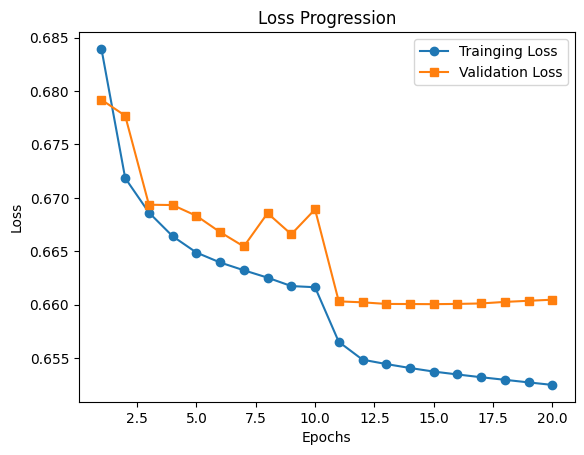

Fold 2
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6807 – acc: 57.40% – f1: 60.27% – precision: 59.87% – recall: 60.69% – roc_auc: 57.17%
Training Fairness Metrics - DPD: 0.3431 – DPR: 0.3643
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6958 acc: 56.79% – f1: 47.51% – precision: 67.35% – recall: 36.70% – roc_auc: 58.20%
Validation Fairness Metrics - DPD: 0.2742 – DPR: 0.0557
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6712 – acc: 59.68% – f1: 60.04% – precision: 63.58% – recall: 56.88% – roc_auc: 59.88%
Training Fairness Metrics - DPD: 0.3378 – DPR: 0.2910
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6731 acc: 57.73% – f1: 53.22% – precision: 64.85% – recall: 45.13% – roc_auc: 58.61%
Validation Fairness Metrics - DPD: 0.2981 – DPR: 0.1961
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6678 – acc: 60.60% – f1: 61.12% – precision: 64.40% – recall: 58.16% – roc_auc: 60.

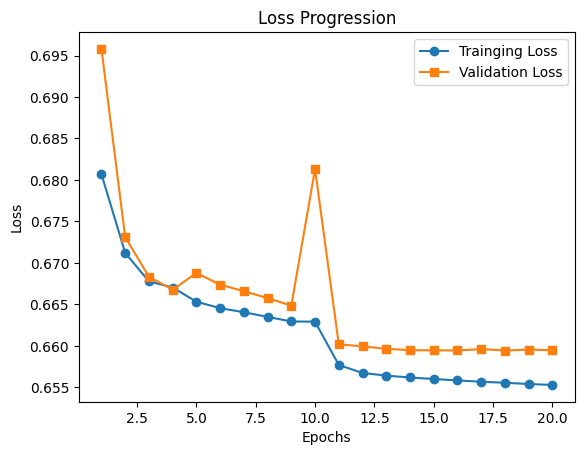

Fold 3
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6837 – acc: 56.60% – f1: 60.41% – precision: 58.73% – recall: 62.19% – roc_auc: 56.21%
Training Fairness Metrics - DPD: 0.3123 – DPR: 0.4462
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6847 acc: 56.59% – f1: 49.51% – precision: 65.11% – recall: 39.94% – roc_auc: 57.76%
Validation Fairness Metrics - DPD: 0.3015 – DPR: 0.0776
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6718 – acc: 59.02% – f1: 58.63% – precision: 63.39% – recall: 54.54% – roc_auc: 59.33%
Training Fairness Metrics - DPD: 0.3054 – DPR: 0.3335
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6808 acc: 58.12% – f1: 54.41% – precision: 64.79% – recall: 46.90% – roc_auc: 58.91%
Validation Fairness Metrics - DPD: 0.2958 – DPR: 0.2330
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6688 – acc: 59.30% – f1: 57.83% – precision: 64.51% – recall: 52.41% – roc_auc: 59.

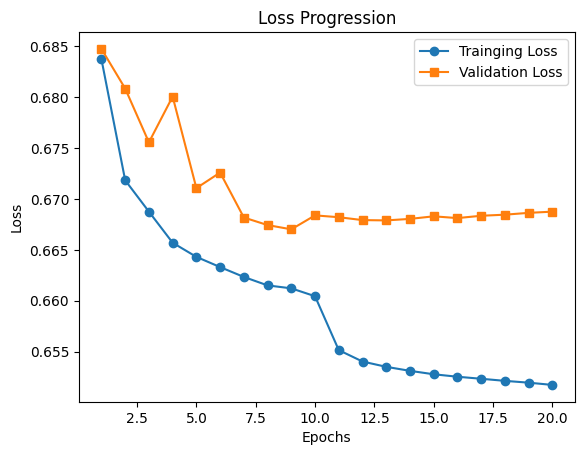

Fold 4
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6888 – acc: 56.24% – f1: 62.99% – precision: 57.31% – recall: 69.92% – roc_auc: 55.28%
Training Fairness Metrics - DPD: 0.2289 – DPR: 0.6477
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6738 acc: 59.41% – f1: 64.14% – precision: 60.54% – recall: 68.18% – roc_auc: 58.80%
Validation Fairness Metrics - DPD: 0.4101 – DPR: 0.3159
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6728 – acc: 58.66% – f1: 58.75% – precision: 62.70% – recall: 55.27% – roc_auc: 58.90%
Training Fairness Metrics - DPD: 0.3342 – DPR: 0.2882
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6660 acc: 60.00% – f1: 61.79% – precision: 62.86% – recall: 60.76% – roc_auc: 59.95%
Validation Fairness Metrics - DPD: 0.3723 – DPR: 0.2765
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6675 – acc: 59.60% – f1: 61.16% – precision: 62.67% – recall: 59.72% – roc_auc: 59.

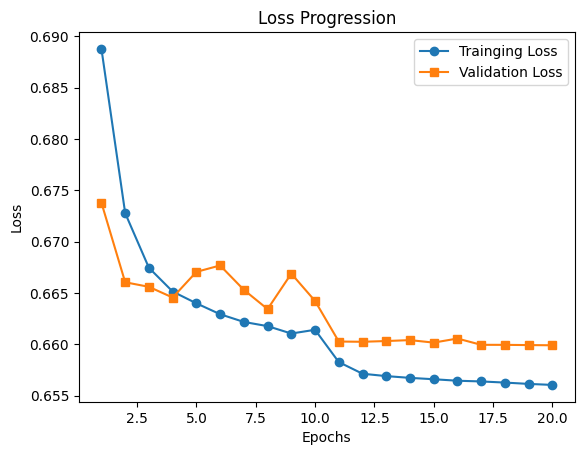

Fold 5
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6842 – acc: 56.81% – f1: 58.64% – precision: 59.85% – recall: 57.47% – roc_auc: 56.76%
Training Fairness Metrics - DPD: 0.3176 – DPR: 0.3792
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6675 acc: 59.01% – f1: 57.57% – precision: 64.12% – recall: 52.23% – roc_auc: 59.48%
Validation Fairness Metrics - DPD: 0.4014 – DPR: 0.0743
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6750 – acc: 58.88% – f1: 58.90% – precision: 62.98% – recall: 55.32% – roc_auc: 59.13%
Training Fairness Metrics - DPD: 0.3309 – DPR: 0.2927
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6696 acc: 58.32% – f1: 52.37% – precision: 66.86% – recall: 43.04% – roc_auc: 59.38%
Validation Fairness Metrics - DPD: 0.2974 – DPR: 0.1322
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6715 – acc: 59.38% – f1: 59.38% – precision: 63.52% – recall: 55.74% – roc_auc: 59.

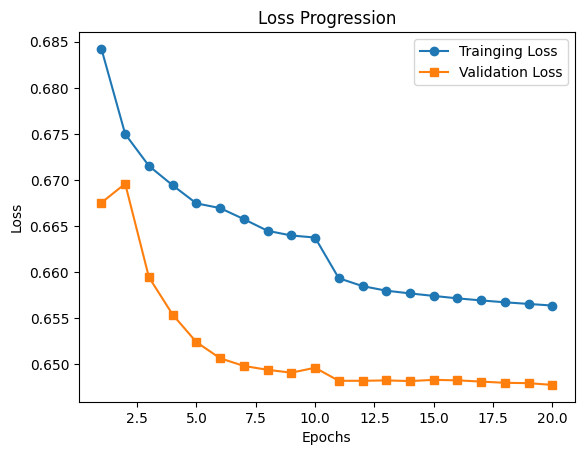

FINAL RESULTS ACROSS ALL FOLDS:
Accuracy:  59.9447479068407 ± 0.6454485411975632
F1-Score:  60.749876919454266 ± 1.195604338218914
Precision:  63.54333925618548 ± 0.8670698376613374
Recall:  58.26135998253037 ± 2.416858816328743
ROC-AUC:  60.06298876203569 ± 0.648581404990561
FINAL FAIRNESS RESULTS ACROSS ALL FOLDS:
Demographic Parity Difference:  0.2878575881219738 ± 0.004390837769274967
Demographic Parity Ratio:  0.40968923751916864 ± 0.02256530782417746


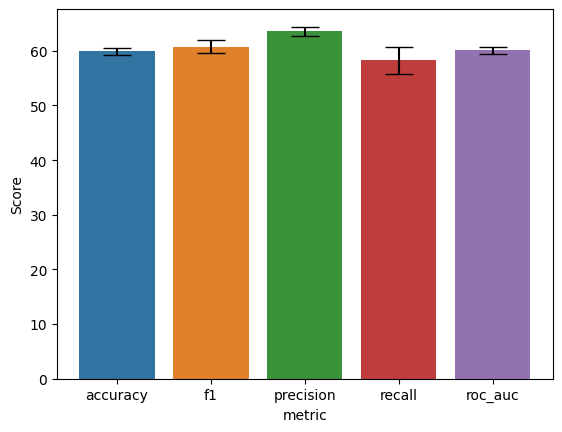

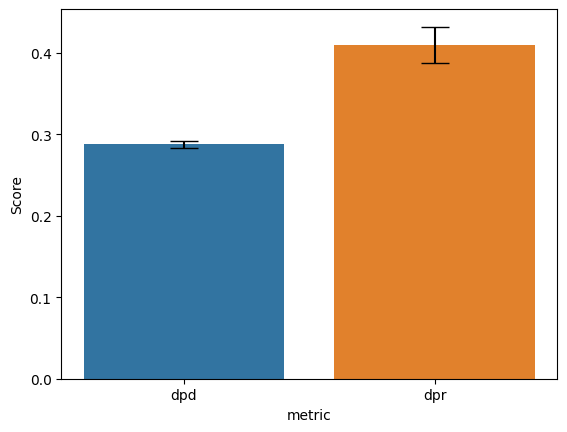

In [100]:
res_base, fair_res_base = kfold_cross_validation(5, X, Y, sensitive_feature=SENSITIVE)

In [101]:
final_df = pd.read_csv('preprocessed_df.csv', index_col=0)

In [102]:
final_df.head()

,s_frequency_of_work_with_teachers,s_frequency_of_evaluations,s_frequency_of_internet_usage,s_extent_of_class_env,s_frequency_of_materials_in_class,s_extent_of_teacher_performance,s_extent_of_classmates_affinity,f_ESCS,s_extent_of_school_satisfaction,s_frequency_of_computer_usage,...,p_number_of_teachers_in_school,p_number_of_years_of_teaching,p_age,p_number_of_years_in_school,p_number_of_years_as_principal,f_mother_education_level,f_frequency_of_see_adult_read,p_number_of_years_as_principal_in_school,p_extent_of_factors_limiting_effectiveness,level_MAT
id_questionnaire,,,,,,,,,,,,,,,,,,,,,
20431,0.700000,0.629630,0.666667,0.583333,0.666667,0.700000,0.761905,1,0.722222,0.444444,...,41.0,30.0,59.0,25.0,16.0,4.0,0.500,16.0,0.291667,1
20432,0.777778,0.814815,0.266667,0.875000,0.476190,0.900000,0.761905,0,0.666667,0.222222,...,41.0,23.0,50.0,17.0,9.0,3.0,0.125,9.0,0.375000,1
20433,0.733333,0.703704,0.400000,0.916667,0.476190,1.000000,1.000000,1,1.000000,0.444444,...,29.0,26.0,55.0,13.0,3.0,3.0,1.000,3.0,0.291667,1
20434,0.633333,0.629630,0.266667,0.750000,0.476190,0.766667,0.904762,0,0.722222,0.666667,...,5.0,20.0,57.0,1.0,2.0,3.0,0.250,1.0,0.625000,0
20435,0.666667,0.629630,0.266667,0.666667,0.523810,0.833333,0.809524,1,0.888889,0.111111,...,57.0,26.0,55.0,4.0,14.0,6.0,0.125,2.0,0.500000,1


### Pre-Processing Mitigation

#### Reweighing

In [103]:
# X_inverted = X.copy()
# X_inverted[SENSITIVE] = 1 - X_inverted[SENSITIVE]

# Y_inverted = Y.copy()
# Y_inverted = 1 - Y_inverted

Fold 1
f_ESCS
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6940 – acc: 53.26% – f1: 69.50% – precision: 53.26% – recall: 100.00% – roc_auc: 50.00%
Training Fairness Metrics - DPD: 0.0000 – DPR: 1.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6891 acc: 53.26% – f1: 69.50% – precision: 53.26% – recall: 100.00% – roc_auc: 50.00%
Validation Fairness Metrics - DPD: 0.0000 – DPR: 1.0000
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6896 – acc: 54.98% – f1: 67.77% – precision: 54.76% – recall: 88.90% – roc_auc: 52.61%
Training Fairness Metrics - DPD: 0.0405 – DPR: 0.9531
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6800 acc: 57.75% – f1: 59.77% – precision: 60.63% – recall: 58.94% – roc_auc: 57.67%
Validation Fairness Metrics - DPD: 0.0647 – DPR: 0.8750
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6811 – acc: 57.20% – f1: 64.68% – precision: 57.70% – recall: 73.60% – roc

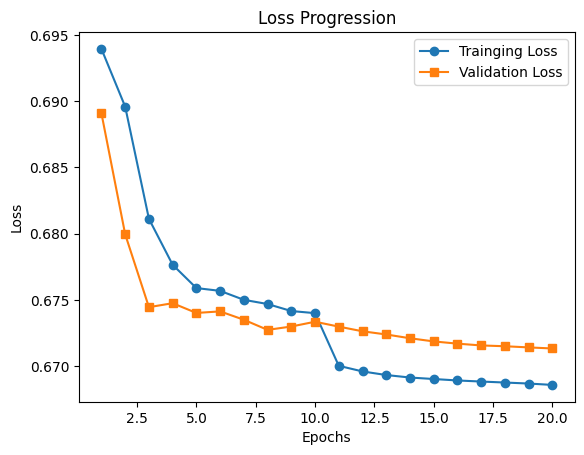

Fold 2
f_ESCS
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6893 – acc: 55.12% – f1: 66.41% – precision: 55.21% – recall: 83.31% – roc_auc: 53.15%
Training Fairness Metrics - DPD: 0.0100 – DPR: 0.9875
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6730 acc: 57.78% – f1: 61.68% – precision: 59.72% – recall: 63.76% – roc_auc: 57.36%
Validation Fairness Metrics - DPD: 0.0214 – DPR: 0.9624
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6813 – acc: 56.91% – f1: 61.65% – precision: 58.59% – recall: 65.04% – roc_auc: 56.34%
Training Fairness Metrics - DPD: 0.0217 – DPR: 0.9646
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6739 acc: 57.83% – f1: 60.65% – precision: 60.31% – recall: 60.98% – roc_auc: 57.61%
Validation Fairness Metrics - DPD: 0.0047 – DPR: 0.9914
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6800 – acc: 57.12% – f1: 62.12% – precision: 58.65% – recall: 66.02% – roc_a

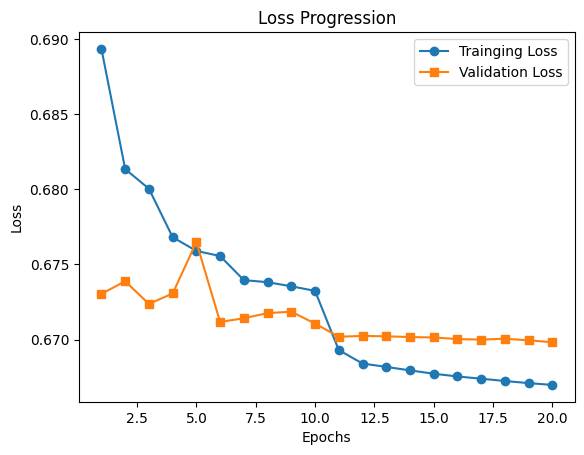

Fold 3
f_ESCS
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6901 – acc: 54.20% – f1: 64.65% – precision: 54.89% – recall: 78.65% – roc_auc: 52.50%
Training Fairness Metrics - DPD: 0.0066 – DPR: 0.9914
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6835 acc: 54.96% – f1: 66.96% – precision: 54.97% – recall: 85.63% – roc_auc: 52.81%
Validation Fairness Metrics - DPD: 0.0134 – DPR: 0.9841
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6797 – acc: 57.56% – f1: 62.80% – precision: 58.89% – recall: 67.27% – roc_auc: 56.89%
Training Fairness Metrics - DPD: 0.0099 – DPR: 0.9841
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6805 acc: 55.51% – f1: 64.32% – precision: 56.15% – recall: 75.25% – roc_auc: 54.12%
Validation Fairness Metrics - DPD: 0.0164 – DPR: 0.9776
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6774 – acc: 57.98% – f1: 62.85% – precision: 59.39% – recall: 66.74% – roc_a

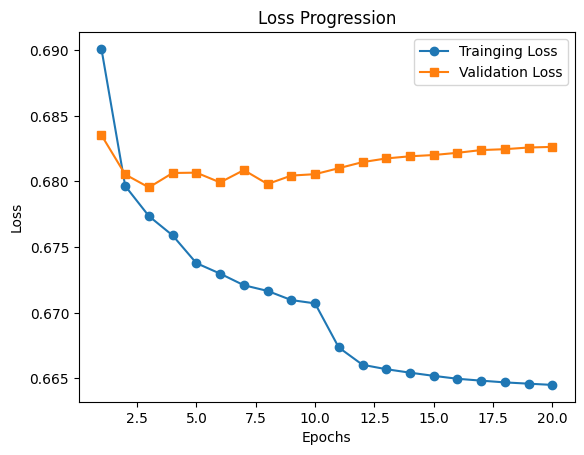

Fold 4
f_ESCS
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6909 – acc: 54.33% – f1: 67.92% – precision: 54.26% – recall: 90.75% – roc_auc: 51.78%
Training Fairness Metrics - DPD: 0.0149 – DPR: 0.9833
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6793 acc: 57.28% – f1: 68.49% – precision: 56.39% – recall: 87.20% – roc_auc: 55.21%
Validation Fairness Metrics - DPD: 0.0276 – DPR: 0.9664
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6807 – acc: 56.91% – f1: 62.17% – precision: 58.38% – recall: 66.49% – roc_auc: 56.24%
Training Fairness Metrics - DPD: 0.0074 – DPR: 0.9878
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6766 acc: 58.12% – f1: 63.91% – precision: 59.04% – recall: 69.67% – roc_auc: 57.33%
Validation Fairness Metrics - DPD: 0.0179 – DPR: 0.9715
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6771 – acc: 57.28% – f1: 63.18% – precision: 58.40% – recall: 68.83% – roc_a

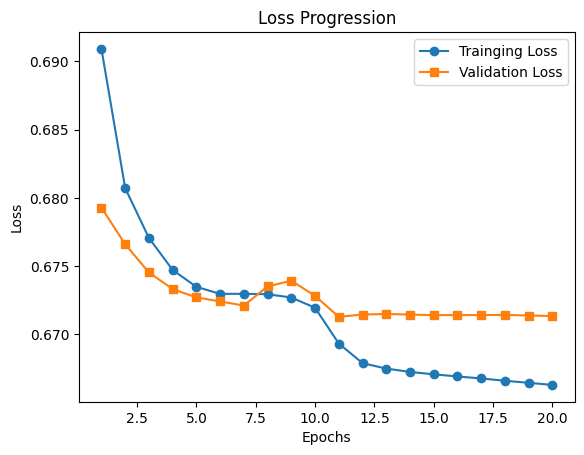

Fold 5
f_ESCS
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6926 – acc: 53.04% – f1: 67.40% – precision: 53.47% – recall: 91.12% – roc_auc: 50.38%
Training Fairness Metrics - DPD: 0.0035 – DPR: 0.9961
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6843 acc: 53.23% – f1: 69.48% – precision: 53.23% – recall: 100.00% – roc_auc: 50.00%
Validation Fairness Metrics - DPD: 0.0000 – DPR: 1.0000
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6851 – acc: 56.08% – f1: 62.04% – precision: 57.48% – recall: 67.37% – roc_auc: 55.29%
Training Fairness Metrics - DPD: 0.0171 – DPR: 0.9726
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6696 acc: 58.57% – f1: 68.06% – precision: 57.71% – recall: 82.93% – roc_auc: 56.88%
Validation Fairness Metrics - DPD: 0.0125 – DPR: 0.9839
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6803 – acc: 56.44% – f1: 61.99% – precision: 57.91% – recall: 66.70% – roc_

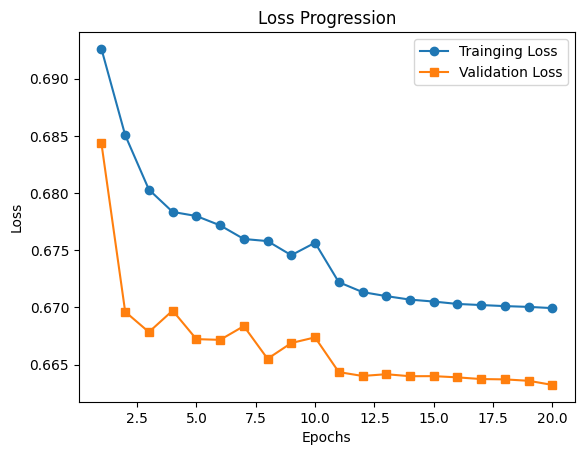

FINAL RESULTS ACROSS ALL FOLDS:
Accuracy:  58.404094914262735 ± 1.1023141803179726
F1-Score:  65.40073459053338 ± 2.112520155610042
Precision:  58.668359202563536 ± 0.43281093322974556
Recall:  74.06044901741976 ± 5.007432911301775
ROC-AUC:  57.31411867991035 ± 0.8833769219162761
FINAL FAIRNESS RESULTS ACROSS ALL FOLDS:
Demographic Parity Difference:  0.013456389408370063 ± 0.010735939649520293
Demographic Parity Ratio:  0.9801054648297935 ± 0.016602146599511782


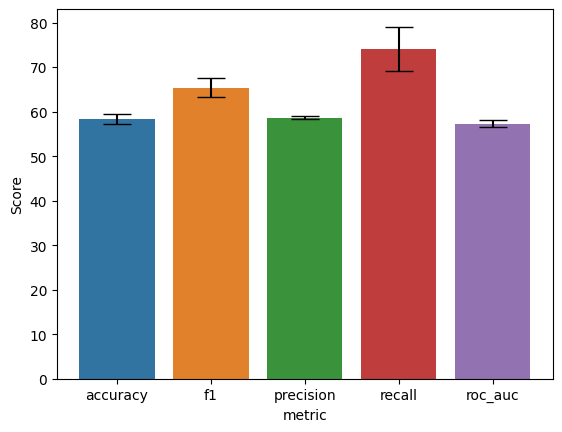

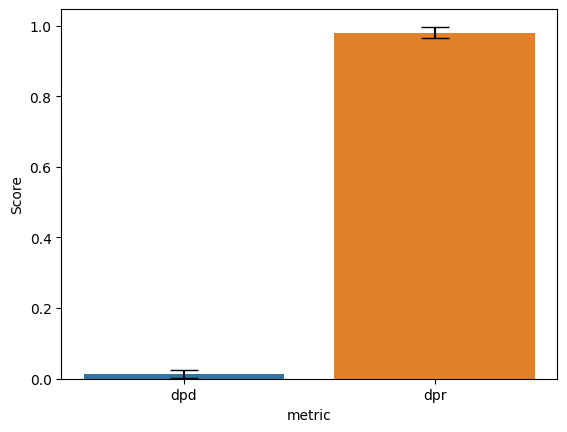

In [104]:
rw_res, rew_fair_res = kfold_cross_validation(5, X, Y, sensitive_feature=SENSITIVE, preprocessing='reweighing')

#### Disparate Impact Remover

Fold 1
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6928 – acc: 52.00% – f1: 51.67% – precision: 55.71% – recall: 48.17% – roc_auc: 52.27%
Training Fairness Metrics - DPD: 0.0000 – DPR: 1.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6856 acc: 55.73% – f1: 42.46% – precision: 68.96% – recall: 30.68% – roc_auc: 57.47%
Validation Fairness Metrics - DPD: 0.1325 – DPR: 0.4406
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6849 – acc: 56.02% – f1: 54.87% – precision: 60.51% – recall: 50.19% – roc_auc: 56.43%
Training Fairness Metrics - DPD: 0.0000 – DPR: 1.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6827 acc: 56.02% – f1: 44.07% – precision: 68.29% – recall: 32.53% – roc_auc: 57.66%
Validation Fairness Metrics - DPD: 0.1368 – DPR: 0.4608
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6832 – acc: 56.37% – f1: 56.26% – precision: 60.36% – recall: 52.69% – roc_auc: 56.

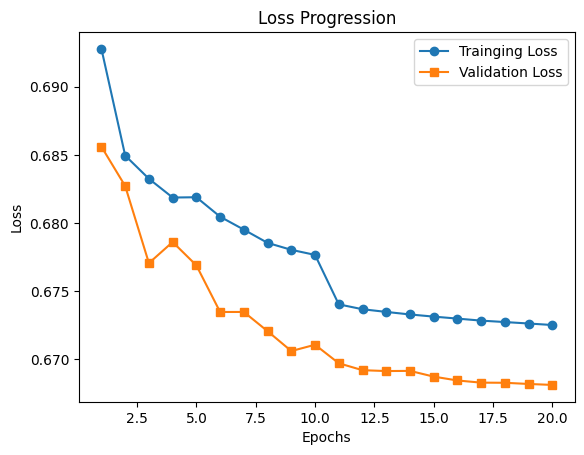

Fold 2
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6960 – acc: 51.55% – f1: 58.85% – precision: 53.72% – recall: 65.07% – roc_auc: 50.61%
Training Fairness Metrics - DPD: 0.0000 – DPR: 1.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6924 acc: 53.58% – f1: 69.58% – precision: 53.46% – recall: 99.63% – roc_auc: 50.34%
Validation Fairness Metrics - DPD: 0.0072 – DPR: 0.9927
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6957 – acc: 50.93% – f1: 52.82% – precision: 54.12% – recall: 51.58% – roc_auc: 50.89%
Training Fairness Metrics - DPD: 0.0000 – DPR: 1.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6920 acc: 55.80% – f1: 40.53% – precision: 71.60% – recall: 28.27% – roc_auc: 57.74%
Validation Fairness Metrics - DPD: 0.1336 – DPR: 0.3649
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6905 – acc: 54.91% – f1: 60.56% – precision: 56.68% – recall: 65.00% – roc_auc: 54.

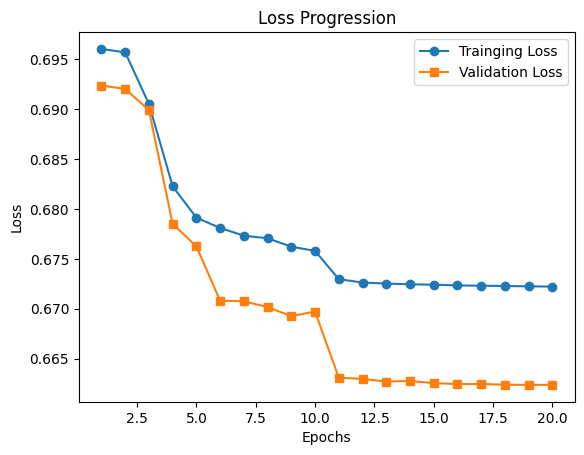

Fold 3
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6911 – acc: 53.49% – f1: 54.29% – precision: 56.95% – recall: 51.88% – roc_auc: 53.60%
Training Fairness Metrics - DPD: 0.0000 – DPR: 1.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6878 acc: 53.04% – f1: 32.12% – precision: 69.88% – recall: 20.85% – roc_auc: 55.30%
Validation Fairness Metrics - DPD: 0.1072 – DPR: 0.3257
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6848 – acc: 55.98% – f1: 53.56% – precision: 61.12% – recall: 47.66% – roc_auc: 56.56%
Training Fairness Metrics - DPD: 0.0000 – DPR: 1.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6799 acc: 56.10% – f1: 46.80% – precision: 66.05% – recall: 36.24% – roc_auc: 57.49%
Validation Fairness Metrics - DPD: 0.1570 – DPR: 0.4628
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6828 – acc: 56.84% – f1: 56.71% – precision: 60.87% – recall: 53.08% – roc_auc: 57.

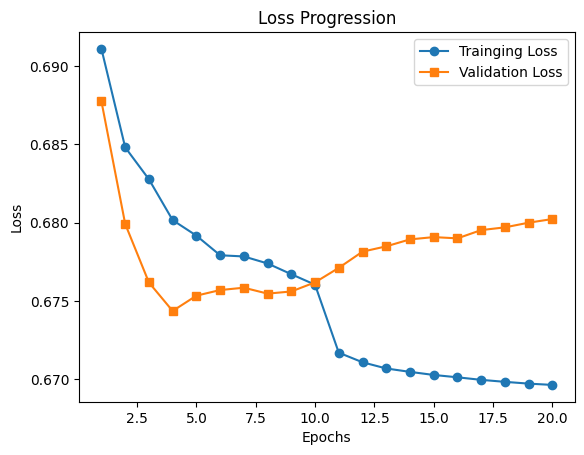

Fold 4
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6940 – acc: 52.57% – f1: 55.91% – precision: 55.38% – recall: 56.45% – roc_auc: 52.30%
Training Fairness Metrics - DPD: 0.0000 – DPR: 1.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6950 acc: 50.27% – f1: 18.72% – precision: 72.05% – recall: 10.76% – roc_auc: 53.00%
Validation Fairness Metrics - DPD: 0.0595 – DPR: 0.2521
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6868 – acc: 54.51% – f1: 50.99% – precision: 59.83% – recall: 44.43% – roc_auc: 55.22%
Training Fairness Metrics - DPD: 0.0000 – DPR: 1.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6742 acc: 57.33% – f1: 48.75% – precision: 67.60% – recall: 38.13% – roc_auc: 58.66%
Validation Fairness Metrics - DPD: 0.1570 – DPR: 0.4772
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6819 – acc: 56.02% – f1: 53.52% – precision: 61.22% – recall: 47.53% – roc_auc: 56.

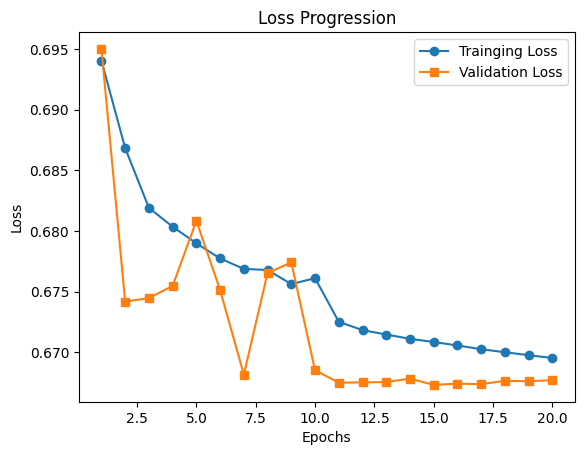

Fold 5
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6961 – acc: 50.64% – f1: 52.48% – precision: 53.85% – recall: 51.17% – roc_auc: 50.60%
Training Fairness Metrics - DPD: 0.0000 – DPR: 1.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6915 acc: 55.36% – f1: 40.21% – precision: 70.05% – recall: 28.20% – roc_auc: 57.24%
Validation Fairness Metrics - DPD: 0.1247 – DPR: 0.4182
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6923 – acc: 53.03% – f1: 50.59% – precision: 57.53% – recall: 45.14% – roc_auc: 53.58%
Training Fairness Metrics - DPD: 0.0000 – DPR: 1.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6727 acc: 59.80% – f1: 61.53% – precision: 62.72% – recall: 60.39% – roc_auc: 59.76%
Validation Fairness Metrics - DPD: 0.1611 – DPR: 0.6857
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6884 – acc: 54.34% – f1: 49.08% – precision: 60.44% – recall: 41.32% – roc_auc: 55.

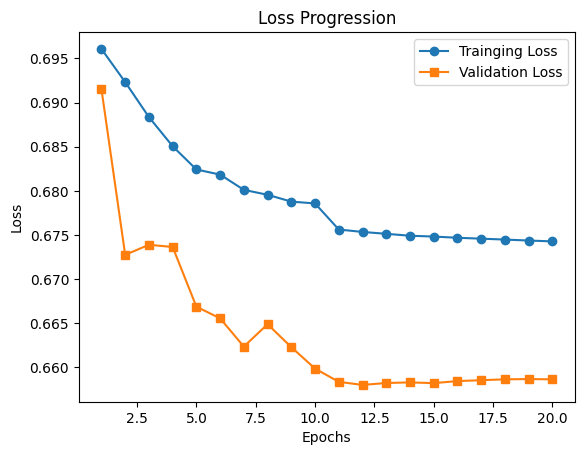

FINAL RESULTS ACROSS ALL FOLDS:
Accuracy:  58.907793743068495 ± 0.8703989725840645
F1-Score:  56.082606137514816 ± 2.1599346363059277
Precision:  65.08746732523284 ± 1.0748011743301944
Recall:  49.397487194389086 ± 3.430053016958185
ROC-AUC:  59.57101187065631 ± 0.7877045409434373
FINAL FAIRNESS RESULTS ACROSS ALL FOLDS:
Demographic Parity Difference:  0.17842933351892323 ± 0.010546292465021766
Demographic Parity Ratio:  0.556241206071631 ± 0.04226230751509537


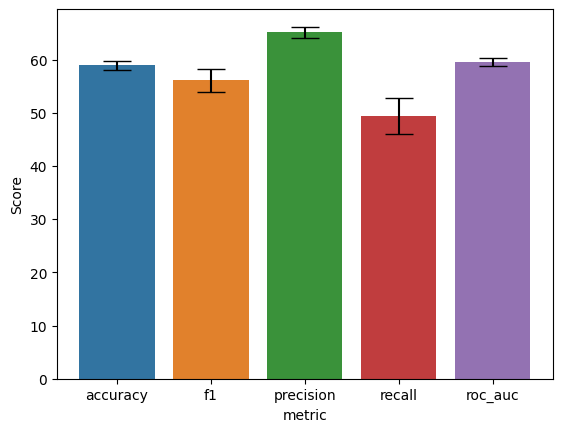

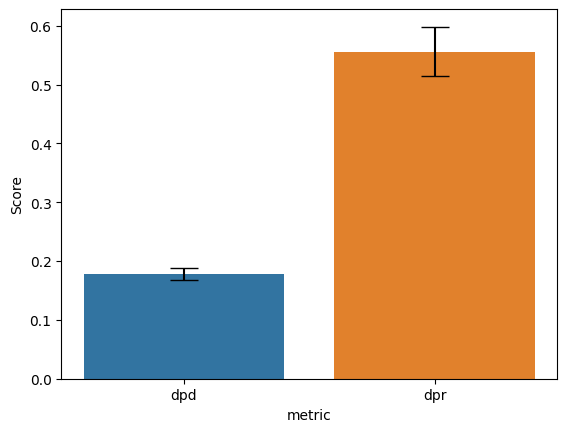

In [105]:
dir_res, dir_fair_res = kfold_cross_validation(5, X, Y, sensitive_feature=SENSITIVE, preprocessing='dir')

#### Learning Fair Representations

Fold 1
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6958 – acc: 51.96% – f1: 61.02% – precision: 53.73% – recall: 70.58% – roc_auc: 50.66%
Training Fairness Metrics - DPD: 0.6996 – DPR: 0.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6916 acc: 53.26% – f1: 69.50% – precision: 53.26% – recall: 100.00% – roc_auc: 50.00%
Validation Fairness Metrics - DPD: 0.0000 – DPR: 1.0000
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6917 – acc: 53.93% – f1: 55.00% – precision: 57.31% – recall: 52.87% – roc_auc: 54.00%
Training Fairness Metrics - DPD: 0.5086 – DPR: 0.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6867 acc: 55.13% – f1: 57.98% – precision: 57.84% – recall: 58.11% – roc_auc: 54.93%
Validation Fairness Metrics - DPD: 0.5350 – DPR: 0.0000
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6889 – acc: 55.07% – f1: 56.58% – precision: 58.30% – recall: 54.96% – roc_auc: 55

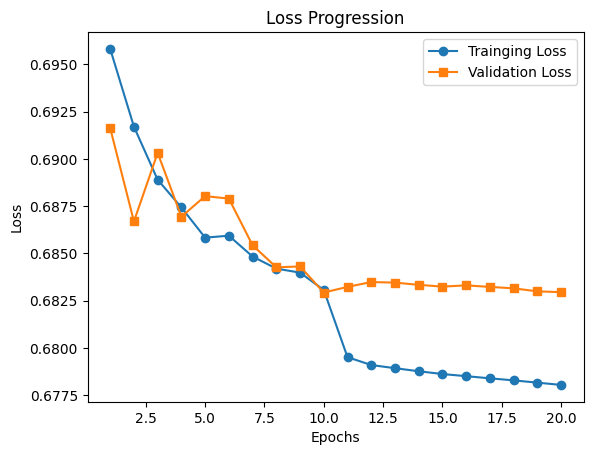

Fold 2
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6953 – acc: 51.86% – f1: 55.18% – precision: 54.72% – recall: 55.66% – roc_auc: 51.59%
Training Fairness Metrics - DPD: 0.5417 – DPR: 0.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6956 acc: 49.28% – f1: 12.89% – precision: 76.00% – recall: 7.04% – roc_auc: 52.25%
Validation Fairness Metrics - DPD: 0.9506 – DPR: 0.0000
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6911 – acc: 55.46% – f1: 59.92% – precision: 57.53% – recall: 62.52% – roc_auc: 54.97%
Training Fairness Metrics - DPD: 0.5787 – DPR: 0.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6835 acc: 53.63% – f1: 42.22% – precision: 62.82% – recall: 31.79% – roc_auc: 55.16%
Validation Fairness Metrics - DPD: 0.7304 – DPR: 0.0000
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6851 – acc: 54.78% – f1: 50.77% – precision: 60.41% – recall: 43.79% – roc_auc: 55.5

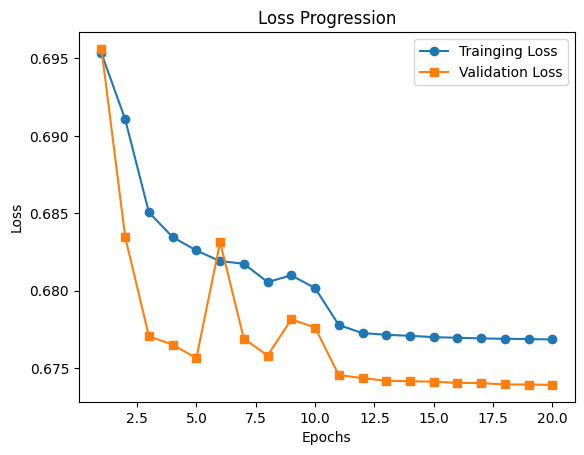

Fold 3
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6956 – acc: 51.66% – f1: 54.85% – precision: 54.56% – recall: 55.15% – roc_auc: 51.42%
Training Fairness Metrics - DPD: 0.5382 – DPR: 0.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6937 acc: 48.69% – f1: 12.76% – precision: 67.86% – recall: 7.04% – roc_auc: 51.62%
Validation Fairness Metrics - DPD: 0.9447 – DPR: 0.0000
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6926 – acc: 52.18% – f1: 51.47% – precision: 56.00% – recall: 47.61% – roc_auc: 52.50%
Training Fairness Metrics - DPD: 0.5472 – DPR: 0.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6882 acc: 52.35% – f1: 54.50% – precision: 55.47% – recall: 53.57% – roc_auc: 52.26%
Validation Fairness Metrics - DPD: 0.5146 – DPR: 0.0000
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6900 – acc: 54.55% – f1: 51.53% – precision: 59.63% – recall: 45.36% – roc_auc: 55.1

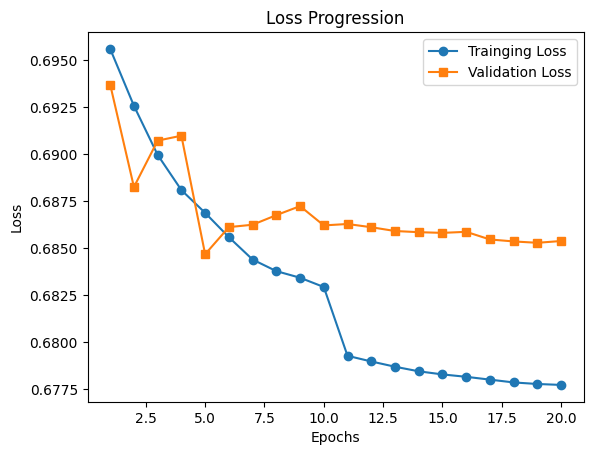

Fold 4
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6954 – acc: 51.22% – f1: 52.64% – precision: 54.50% – recall: 50.89% – roc_auc: 51.24%
Training Fairness Metrics - DPD: 0.5027 – DPR: 0.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6937 acc: 46.91% – f1: 2.01% – precision: 57.89% – recall: 1.02% – roc_auc: 50.09%
Validation Fairness Metrics - DPD: 0.9906 – DPR: 0.0000
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6946 – acc: 51.70% – f1: 52.47% – precision: 55.13% – recall: 50.06% – roc_auc: 51.81%
Training Fairness Metrics - DPD: 0.5164 – DPR: 0.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6909 acc: 54.27% – f1: 44.22% – precision: 63.06% – recall: 34.04% – roc_auc: 55.67%
Validation Fairness Metrics - DPD: 0.7126 – DPR: 0.0000
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6936 – acc: 51.19% – f1: 42.51% – precision: 57.04% – recall: 33.88% – roc_auc: 52.40

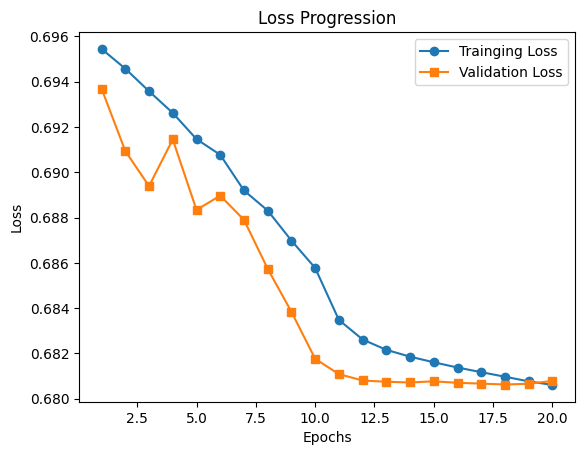

Fold 5
Epoch 01
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6960 – acc: 50.69% – f1: 54.01% – precision: 53.66% – recall: 54.37% – roc_auc: 50.43%
Training Fairness Metrics - DPD: 0.5397 – DPR: 0.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6904 acc: 56.40% – f1: 50.86% – precision: 63.56% – recall: 42.39% – roc_auc: 57.36%
Validation Fairness Metrics - DPD: 0.6449 – DPR: 0.0000
Epoch 02
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6941 – acc: 51.96% – f1: 50.09% – precision: 56.07% – recall: 45.26% – roc_auc: 52.42%
Training Fairness Metrics - DPD: 0.5701 – DPR: 0.0000
Sensitive feature is f_ESCS
Validation General Metrics - loss: 0.6859 acc: 52.99% – f1: 36.36% – precision: 65.07% – recall: 25.23% – roc_auc: 54.91%
Validation Fairness Metrics - DPD: 0.7936 – DPR: 0.0000
Epoch 03
Sensitive feature is f_ESCS
Training General Metrics - loss: 0.6911 – acc: 53.44% – f1: 53.25% – precision: 57.23% – recall: 49.78% – roc_auc: 53.

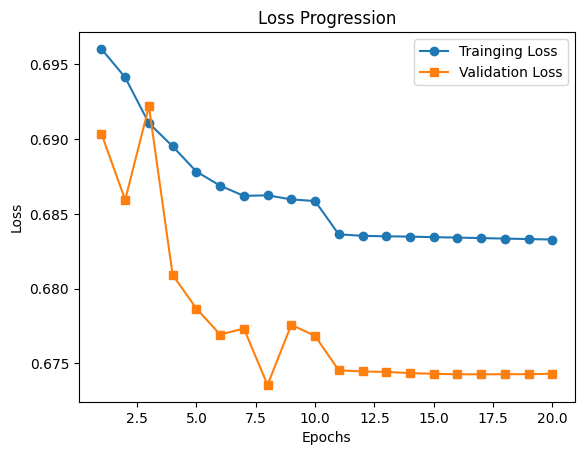

FINAL RESULTS ACROSS ALL FOLDS:
Accuracy:  56.34014112829512 ± 1.660883776301832
F1-Score:  56.16051897123013 ± 3.275777081104498
Precision:  60.253797231964676 ± 1.2311381647094801
Recall:  52.77299292789827 ± 5.039183212872771
ROC-AUC:  56.59004343881803 ± 1.4773606313991334
FINAL FAIRNESS RESULTS ACROSS ALL FOLDS:
Demographic Parity Difference:  0.5385184210205598 ± 0.0354395570419467
Demographic Parity Ratio:  0.0 ± 0.0


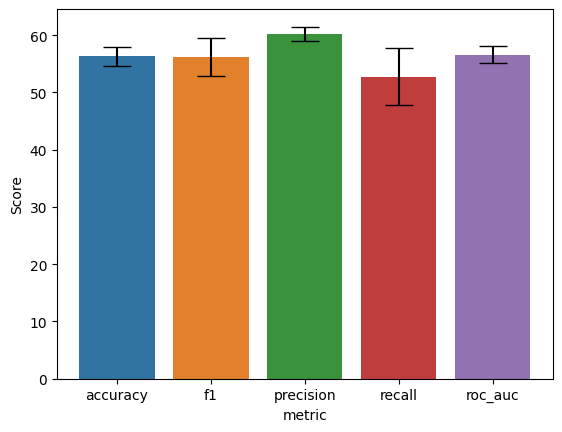

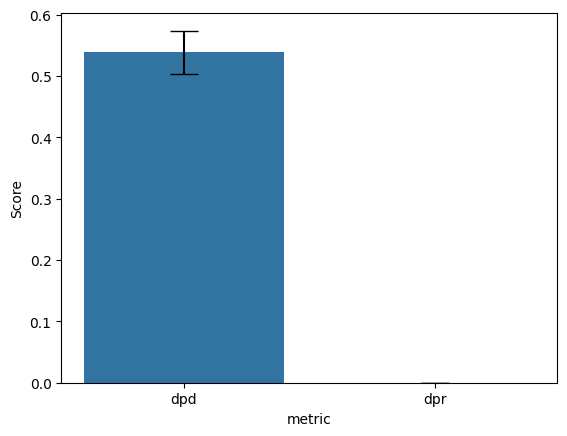

In [106]:
lfr_res, lfr_fair_res = kfold_cross_validation(5, X, Y, sensitive_feature=SENSITIVE, preprocessing='lfr')

### In-Processing Mitigation

#### Adversarial Debiasing

Fold 1
Sensitive feature is f_ESCS
Validation General Metrics -  acc: 59.03% – f1: 61.86% – precision: 61.35% – recall: 62.37% – roc_auc: 58.80%
Validation Fairness Metrics - DPD: 0.1615 – DPR: 0.7017
Fold 2
Sensitive feature is f_ESCS
Validation General Metrics -  acc: 59.70% – f1: 63.34% – precision: 61.46% – recall: 65.34% – roc_auc: 59.31%
Validation Fairness Metrics - DPD: 0.1927 – DPR: 0.6598
Fold 3
Sensitive feature is f_ESCS
Validation General Metrics -  acc: 61.38% – f1: 63.63% – precision: 63.87% – recall: 63.39% – roc_auc: 61.24%
Validation Fairness Metrics - DPD: 0.1885 – DPR: 0.6436
Fold 4
Sensitive feature is f_ESCS
Validation General Metrics -  acc: 60.54% – f1: 64.54% – precision: 61.87% – recall: 67.44% – roc_auc: 60.07%
Validation Fairness Metrics - DPD: 0.1724 – DPR: 0.7028
Fold 5
Sensitive feature is f_ESCS
Validation General Metrics -  acc: 61.98% – f1: 63.40% – precision: 65.01% – recall: 61.87% – roc_auc: 61.98%
Validation Fairness Metrics - DPD: 0.1592 – DPR: 0.

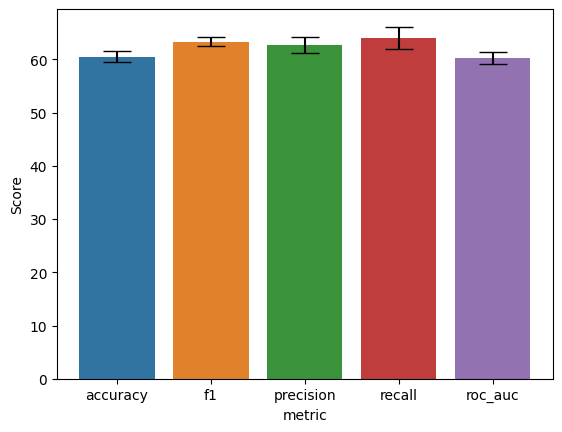

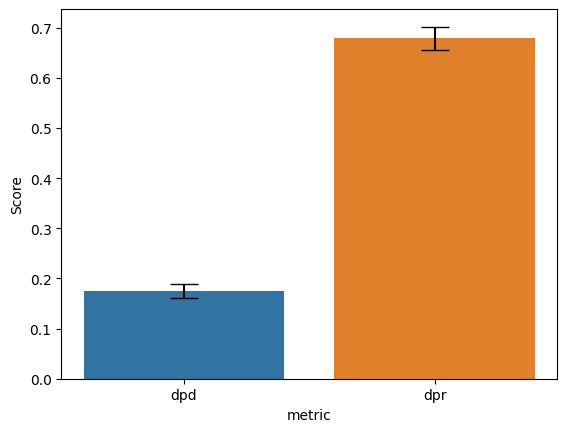

In [108]:
ad_res, ad_fair_res = kfold_cross_validation(5, X, Y, sensitive_feature=SENSITIVE, inprocessing='adversarial_debiasing')

#### FaUCI

Fold 1
Sensitive feature is f_ESCS
Validation General Metrics -  acc: 55.97% – f1: 44.11% – precision: 68.09% – recall: 32.62% – roc_auc: 57.60%
Validation Fairness Metrics - DPD: 0.1926 – DPR: 0.2454
Fold 2
Sensitive feature is f_ESCS
Validation General Metrics -  acc: 56.94% – f1: 43.96% – precision: 71.70% – recall: 31.70% – roc_auc: 58.71%
Validation Fairness Metrics - DPD: 0.1790 – DPR: 0.2401
Fold 3
Sensitive feature is f_ESCS
Validation General Metrics -  acc: 56.15% – f1: 43.08% – precision: 69.85% – recall: 31.14% – roc_auc: 57.91%
Validation Fairness Metrics - DPD: 0.1995 – DPR: 0.1602
Fold 4
Sensitive feature is f_ESCS
Validation General Metrics -  acc: 56.74% – f1: 41.60% – precision: 73.93% – recall: 28.94% – roc_auc: 58.66%
Validation Fairness Metrics - DPD: 0.1563 – DPR: 0.2500
Fold 5
Sensitive feature is f_ESCS
Validation General Metrics -  acc: 56.74% – f1: 40.65% – precision: 75.38% – recall: 27.83% – roc_auc: 58.74%
Validation Fairness Metrics - DPD: 0.1563 – DPR: 0.

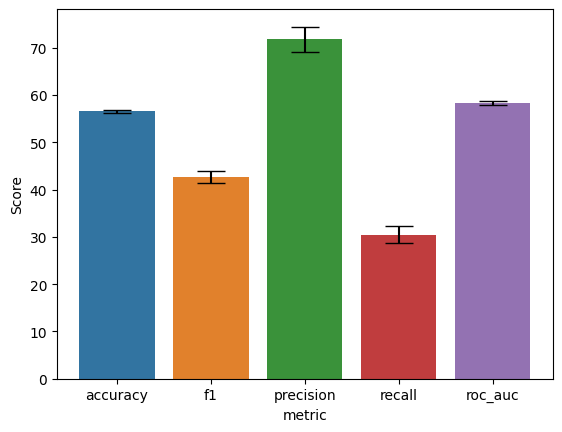

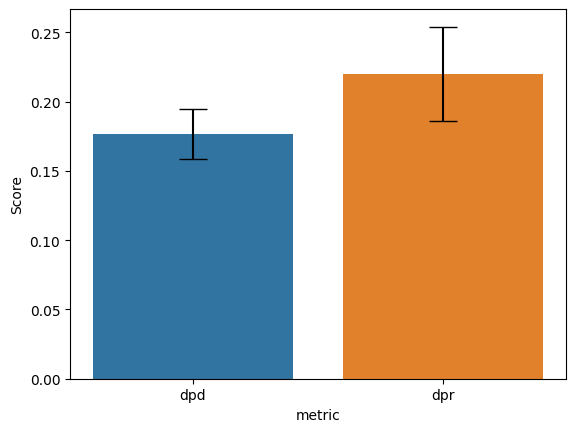

In [109]:
fauci_res, fauci_fair_res = kfold_cross_validation(5, X, Y, sensitive_feature=SENSITIVE, inprocessing='FaUCI')

#### Prejudice Remover

Fold 1
Sensitive feature is f_ESCS
Validation General Metrics -  acc: 54.74% – f1: 35.83% – precision: 73.14% – recall: 23.73% – roc_auc: 56.90%
Validation Fairness Metrics - DPD: 0.1373 – DPR: 0.2054
Fold 2
Sensitive feature is f_ESCS
Validation General Metrics -  acc: 59.46% – f1: 58.39% – precision: 64.43% – recall: 53.38% – roc_auc: 59.88%
Validation Fairness Metrics - DPD: 0.2829 – DPR: 0.3592
Fold 3
Sensitive feature is f_ESCS
Validation General Metrics -  acc: 53.48% – f1: 34.40% – precision: 69.19% – recall: 22.89% – roc_auc: 55.63%
Validation Fairness Metrics - DPD: 0.1541 – DPR: 0.1259
Fold 4
Sensitive feature is f_ESCS
Validation General Metrics -  acc: 59.75% – f1: 54.03% – precision: 68.92% – recall: 44.43% – roc_auc: 60.81%
Validation Fairness Metrics - DPD: 0.2310 – DPR: 0.3270
Fold 5
Sensitive feature is f_ESCS
Validation General Metrics -  acc: 59.01% – f1: 50.77% – precision: 70.39% – recall: 39.70% – roc_auc: 60.35%
Validation Fairness Metrics - DPD: 0.2398 – DPR: 0.

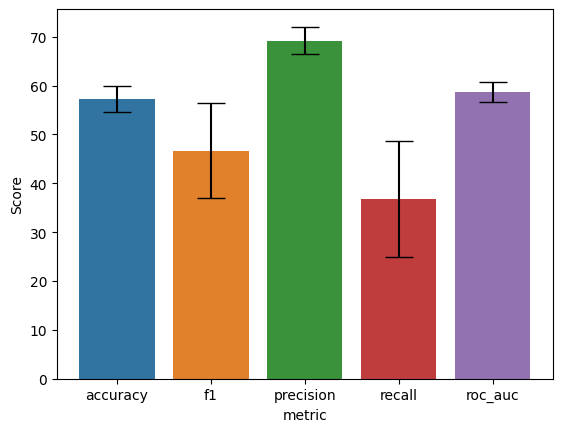

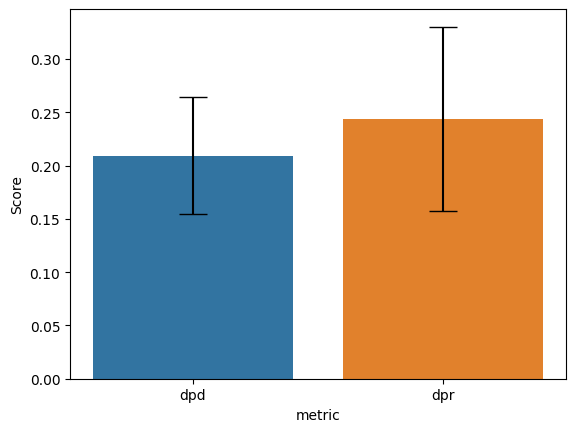

In [110]:
pr_res, pr_fair_res = kfold_cross_validation(5, X, Y, sensitive_feature=SENSITIVE, inprocessing='prejudice_remover')